# CONFLUENCE Tutorial - 3: Lumped Basin Workflow (East River at Almont)

## Introduction

## Lumped Basin Modeling Philosophy
Lumped basin modeling treats the entire watershed as one homogeneous computational unit, spatially averaging all variability across the catchment. This approach establishes baseline performance by determining whether a model can capture fundamental watershed response before adding spatial complexity, while its simplified parameter structure facilitates clear understanding of which parameters control model behavior and hydrological processes.

## Case Study: East River at Almont
Here, we focus on the East River at Almont watershed, located in the Sierra Nevada of Colorado, US. This watershed encompasses approximately *1,958* km² with elevations ranging from *3,500* m at the outlet to over *8,600* m in the headwaters, representing a snow-dominated mountain system with pronounced seasonal cycles. The basin is monitored by USGS station 09112500, which provides long-term streamflow observations essential for model validation.

## Step 1: Basin-Scale Workflow Setup
Building on the point-scale modeling expertise from Tutorials 01a and 01b, we now advance to basin-scale hydrological modeling. This represents a scaling transition from process validation at individual sites to integrated watershed simulation that captures the collective hydrological response of an entire catchment.

The same CONFLUENCE architecture seamlessly handles this transition, demonstrating the framework's scalability from point validation through basin-scale prediction while maintaining reproducible workflow principles.

In [1]:
import os
# change to CONFLUENCE root directory
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [2]:
# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# import custom utility functions
from utils.custom.calc import *
from utils.custom.plotting import *
from utils.custom.adjust_settings import *

# Set up plotting style
plt.style.use('default')
%matplotlib inline

In [3]:
today = datetime.today().strftime('%Y%m%d')
relevant_detail = 'model_testing'  # Update this based on the specific model configuration (e.g., 'lumped', 'semi_distributed')
name = f'{today}_{relevant_detail}'
# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED EAST RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for lumped modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_East_River_lumped.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for lumped East River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'East_River_lumped',
    'EXPERIMENT_ID': f'{name}',  # Update experiment ID
    'DOMAIN_DEFINITION_METHOD': 'lumped',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Lumped',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2007-10-01 00:00',
    'EXPERIMENT_TIME_END':  '2016-09-30 23:00',
    'CALIBRATION_PERIOD': '2009-10-01, 2012-09-30',
    'EVALUATION_PERIOD': '2012-10-01, 2015-09-30',
    'SPINUP_PERIOD': '2007-10-01, 2009-09-30',
    'MPI_PROCESSES': 4,                       # Adjust based on available resources
    'SETTINGS_SUMMA_COLDSTATE': 'coldState_updated.nc',  # Updated cold state file with new layer structure
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'DELINEATION_METHOD': 'TauDEM',  # Changed from 'TauDEM'
    'CATCHMENT_SHP_HRUID': 'HRU_ID',          # Updated HRU ID field
    'CATCHMENT_SHP_GRUID': 'GRU_ID',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
    'ROUTING_DELINEATION': 'lumped',        # Changed to 'lumped' or remove
    'APPLY_LAPSE_RATE': False,                 # Changed to True to apply lapse rate
    'OPTIMIZATION_METRIC': 'NSE',          # Changed to 'NSE' for emulation
    'ITERATIVE_OPTIMIZATION_ALGORITHM': 'DDS',  # Changed to 'DDS' for optimization
    'NUMBER_OF_ITERATIONS': 12,
    'BASIN_PARAMS_TO_CALIBRATE': 'basin__aquiferScaleFactor, basin__aquiferHydCond',
    'PARAMS_TO_CALIBRATE': 'k_soil, theta_sat, theta_res, aquiferScaleFactor, rootingDepth',
    'SUMMA_RUNOFF_VAR': 'scalarTotalRunoff'    # Use scalarTotalRunoff for calibration (not averageRoutedRunoff)
}

config_dict.update(config_updates)

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_East_River_lumped.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")
print(f"Basin Parameters to Calibrate: {confluence.config['BASIN_PARAMS_TO_CALIBRATE']}")

2026-03-24 12:32:40 ● CONFLUENCE Logging Initialized
2026-03-24 12:32:40 ● Domain: East_River_lumped
2026-03-24 12:32:40 ● Experiment ID: 20260324_model_testing
2026-03-24 12:32:40 ● Log Level: INFO
2026-03-24 12:32:40 ● Log File: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/_workLog_East_River_lumped/confluence_general_East_River_lumped_20260324_123240.log
2026-03-24 12:32:41 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/_workLog_East_River_lumped/config_East_River_lumped_20260324_123240.yaml
2026-03-24 12:32:41 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA


2026-03-24 12:32:41 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_lumped.yaml
=== Directory Configuration ===
Code Directory: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
Data Directory: /scratch/dlhogan/ess-project-data

=== Key Configuration Settings ===
Domain Name: East_River_lumped
Pour Point: 38.66443715/-106.848095
Spatial Mode: Lumped
Model: SUMMA
Simulation Period: 2007-10-01 00:00 to 2016-09-30 23:00
Basin Parameters to Calibrate: basin__aquiferScaleFactor, basin__aquiferHydCond


### Model Decision & Parameter Changes

#### Update coldstate

In [4]:
import xarray as xr
ds = xr.open_dataset("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA/coldState.nc")

In [5]:
SETTINGS_DIR = CONFLUENCE_DATA_DIR / f"domain_{confluence.config['DOMAIN_NAME']}" / 'settings' / 'SUMMA'
source_path = SETTINGS_DIR / 'coldState.nc'
target_path = SETTINGS_DIR / 'coldState_updated.nc'
tmp_path = SETTINGS_DIR / 'coldState_updated.tmp.nc'

source_stat_before = source_path.stat()

# Fully load into memory so edits are detached from the on-disk source file.
with xr.load_dataset(source_path) as source_ds:
    coldState = source_ds.copy(deep=True)

# -----------------------------------------------------------------------------
# USER-DEFINED SOIL GEOMETRY
# Edit these lists directly to control the coldState structure.
# `target_interfaces` are cumulative interface depths from the surface.
# `target_layer_depths` are per-layer depths/thicknesses.
# For LUMPED models, HRU is always 1 (do not inherit from source).
# -----------------------------------------------------------------------------
target_interfaces = [0.0, 0.2, 0.5, 1.0, 3.0]
target_layer_depths = [0.2, 0.3, 0.5, 2.0]

target_interfaces = np.asarray(target_interfaces, dtype=float)
target_layer_depths = np.asarray(target_layer_depths, dtype=float)

if target_interfaces.ndim != 1 or target_layer_depths.ndim != 1:
    raise ValueError("target_interfaces and target_layer_depths must be 1D lists")
if len(target_interfaces) != len(target_layer_depths) + 1:
    raise ValueError(
        f"Need len(target_interfaces) = len(target_layer_depths) + 1, got {len(target_interfaces)} and {len(target_layer_depths)}"
    )
if not np.all(np.diff(target_interfaces) > 0):
    raise ValueError("target_interfaces must be strictly increasing")
if not np.isclose(target_interfaces[0], 0.0):
    raise ValueError("target_interfaces must start at 0.0")
if np.any(target_layer_depths <= 0):
    raise ValueError("target_layer_depths must all be positive")
if not np.isclose(target_interfaces[-1], target_layer_depths.sum()):
    raise ValueError(
        f"Bottom interface ({target_interfaces[-1]}) must equal sum(target_layer_depths) ({target_layer_depths.sum()})"
    )

# FORCE: lumped model always has 1 HRU, do NOT inherit from source
num_hru = 1
num_scalar = coldState.sizes["scalarv"]
num_layers = len(target_layer_depths)
num_interfaces = len(target_interfaces)

coords = {
    "hru": np.array([1]),  # Lumped: always single HRU with id=1
    "scalarv": coldState["scalarv"].values,
    "midToto": np.arange(num_layers),
    "ifcToto": np.arange(num_interfaces),
    "midSoil": np.arange(num_layers)
}
# if "midSoil" in coldState.dims:
#     coords["midSoil"] = np.arange(num_layers)

coldState_updated = xr.Dataset(coords=coords, attrs=coldState.attrs)

# Copy variables, taking only the first HRU from source (or creating fresh) and keeping exactly 1 HRU.
for var in coldState.data_vars:
    values = coldState[var].values
    dims = coldState[var].dims

    if dims == ("midToto", "hru"):
        # Take last layer from source, replicate to new num_layers, keep single HRU
        fill_values = np.repeat(values[-1:, 0:1], num_layers, axis=0)
        coldState_updated[var] = (("midToto", "hru"), fill_values)
    elif dims == ("ifcToto", "hru"):
        # Take last interface from source, replicate to new num_interfaces, keep single HRU
        fill_values = np.repeat(values[-1:, 0:1], num_interfaces, axis=0)
        coldState_updated[var] = (("ifcToto", "hru"), fill_values)
    elif dims == ("midSoil", "hru"):
        # Take last soil value from source, replicate to new num_layers, keep single HRU
        fill_values = np.repeat(values[-1:, 0:1], num_layers, axis=0)
        coldState_updated[var] = (("midSoil", "hru"), fill_values)
    elif dims == ("scalarv", "hru"):
        if var == "nSoil":
            # Set nSoil to the new number of layers
            coldState_updated[var] = (("scalarv", "hru"), np.array([[num_layers]], dtype=values.dtype))
        else:
            # Keep first HRU's scalar value
            coldState_updated[var] = (("scalarv", "hru"), values[:, 0:1])
    elif "hru" in dims:
        # Any other HRU-dependent var: take first HRU only
        dims_idx = {d: slice(None) if d != "hru" else 0 for d in dims}
        coldState_updated[var] = coldState[var].isel(**{d: s if isinstance(s, slice) else [s] for d, s in dims_idx.items()})
    else:
        # Non-HRU variables: copy as-is
        coldState_updated[var] = coldState[var].copy(deep=True)

# Overwrite the soil geometry with the explicit user-defined values (single HRU).
coldState_updated["iLayerHeight"] = (
    ("ifcToto", "hru"),
    np.column_stack([target_interfaces]),  # Shape (num_interfaces, 1)
)
coldState_updated["mLayerDepth"] = (
    ("midToto", "hru"),
    np.column_stack([target_layer_depths]),  # Shape (num_layers, 1)
)

# Write atomically: create a temp file, then replace the target.
if tmp_path.exists():
    tmp_path.unlink()
coldState_updated.to_netcdf(tmp_path)
tmp_path.replace(target_path)

source_stat_after = source_path.stat()

print(f"Source file: {source_path}")
print(f"Updated file: {target_path}")
print(f"Source unchanged: {source_stat_before.st_size == source_stat_after.st_size and source_stat_before.st_mtime_ns == source_stat_after.st_mtime_ns}")
print(f"Original dims: {dict(coldState.sizes)}")
print(f"Updated dims: {dict(coldState_updated.sizes)}")
print(f"✓ HRUs forced to 1 (lumped)")
print(f"Interfaces used: {target_interfaces}")
print(f"Layer depths used: {target_layer_depths}")

Source file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/coldState.nc
Updated file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/coldState_updated.nc
Source unchanged: True
Original dims: {'hru': 1, 'scalarv': 1, 'midToto': 3, 'ifcToto': 4}
Updated dims: {'hru': 1, 'scalarv': 1, 'midToto': 4, 'ifcToto': 5, 'midSoil': 4}
✓ HRUs forced to 1 (lumped)
Interfaces used: [0.  0.2 0.5 1.  3. ]
Layer depths used: [0.2 0.3 0.5 2. ]


In [6]:
# =============================================================================
# PARAMETER AND MANUAL MODEL SETUP FOR STANDARD RUNS
# ============================================================================= 
# NOTE: For DDS parameter calibration optimization, use: python optimize_confluence.py
# The standalone script handles all parameter management and preprocessing automatically.

from utils.custom.adjust_settings import edit_modelDecisions, update_and_reformat_parameter_file, _format_parameter_value

# Define base settings paths (READ ONLY - do not modify!)
base_settings_dir = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_base_settings/SUMMA")

# Define working copy directory in scratch
project_settings_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "settings" / "SUMMA"
project_settings_dir.mkdir(parents=True, exist_ok=True)

print("📋 Setting up parameters for manual run...")

# Copy base settings
for fname in ["modelDecisions.txt", "localParamInfo.txt", "basinParamInfo.txt"]:
    shutil.copy(base_settings_dir / fname, project_settings_dir / fname)

modelDecision_file = project_settings_dir / "modelDecisions.txt"
localParamInfo_file = project_settings_dir / "localParamInfo.txt"
basinParamInfo_file = project_settings_dir / "basinParamInfo.txt"

# Update model decisions
edit_modelDecisions(modelDecision_file, {
    'groundwatr': 'noXplict', # groundwater not explicitly simulated in this configuration
    'bcLowrSoiH': 'zeroFlux', # zero flux to the lower soil boundary. this eliminates any 
    'spatial_gw': 'localColumn',
    'hcProfile' : 'constant', # constant hydrological conductivity profile (no depth variation)
    'stomResist': 'Jarvis'
})

# Manual parameter values for this run
print("\n✏️  Using manually specified parameter values...")
localParamInfo_updates = {
    'tempCritRain': 275.1000,
    'k_soil': 2.0e-5,
    'theta_sat': 0.4000, # somewhere in the sandy-loam territory
    'theta_res': 0.0500,
    'rootingDepth': 2.5000, # for 3-m deep soils
    'vGn_alpha': -2.0000, # faster drainage
    'qSurfScale': 100.0000, # changes the infiltration area
    # 'f_impede': 5.0000,
}

basinParamInfo_updates = {
    "basin__aquiferHydCond": 0.0010,
    "basin__aquiferScaleFactor": 50.0000,
    "routingGammaShape": 2.5000,
    "routingGammaScale": 4.6e4,
}

# Robust parameter updater with fallback
def _apply_updates_with_fallback(file_path, updates):
    """Try standard updater, fall back to pipe-delimited replacement if needed."""
    res = update_and_reformat_parameter_file(file_path, updates, reformat_all=True)
    updated_count = int(res.get('updated_count', 0)) if isinstance(res, dict) else 0
    if updated_count > 0:
        return updated_count
    
    # Fallback: syntax-preserving pipe-delimited replacement
    with open(file_path, 'r') as f:
        lines = f.readlines()
    
    new_lines = []
    n = 0
    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith('!') or '|' not in line:
            new_lines.append(line)
            continue
        
        parts = line.rstrip('\n').split('|')
        if len(parts) < 4:
            new_lines.append(line)
            continue
        
        key = parts[0].strip()
        if key in updates:
            parts[1] = f" {_format_parameter_value(updates[key])} "
            line = '|'.join(parts) + '\n'
            n += 1
        
        new_lines.append(line)
    
    if n > 0:
        with open(file_path, 'w') as f:
            f.writelines(new_lines)
    
    return n

# Update parameter files with feedback
print("\n  Local parameters:")
n_local = _apply_updates_with_fallback(localParamInfo_file, localParamInfo_updates)
for key, value in localParamInfo_updates.items():
    print(f"    {key}: {value}")
print(f"  ✓ Updated {n_local} local parameters")

# print("\n  Basin parameters:")
n_basin = _apply_updates_with_fallback(basinParamInfo_file, basinParamInfo_updates)
for key, value in basinParamInfo_updates.items():
    print(f"    {key}: {value}")
print(f"  ✓ Updated {n_basin} basin parameters")

print(f"\n✓ All parameters updated at: {project_settings_dir}")

📋 Setting up parameters for manual run...

✏️  Using manually specified parameter values...

  Local parameters:
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
    tempCritRain: 275.1
    k_soil: 2e-05
    theta_sat: 0.4
    theta_res: 0.05
    rootingDepth: 2.5
    vGn_alpha: -2.0
    qSurfScale: 100.0
  ✓ Updated 7 local parameters
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
    basin__aquiferHydCond: 0.001
    basin__aquiferScaleFactor: 50.0
    routingGammaShape: 2.5
    routingGammaScale: 46000.0
  ✓ Updated 4 basin parameters

✓ All parameters updated at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA


In [7]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

2026-03-24 12:32:41 ● Setting up project for domain: East_River_lumped
2026-03-24 12:32:41 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped
2026-03-24 12:32:41 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/pour_point/East_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_East_River_lumped
  📁 attributes
  📁 forcing
  📁 observations
  📁 optimisation
  📁 plots
  📁 seasonal_ensemble
  📁 settings
  📁 shapefiles
  📁 simulations

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Step 2: Basin Representation and Spatial Discretization Fundamentals
The transition from point-scale to basin-scale modeling requires fundamental decisions about how to represent spatial heterogeneity within the watershed. Unlike point-scale modeling where we assume uniform conditions, basin-scale modeling must address the challenge of capturing spatial variability.

### Scientific Context: Basin Representation Philosophy
Basin-scale hydrological modeling confronts significant spatial heterogeneity challenges that profoundly influence water cycling processes. 
- Elevation gradients create complex patterns in temperature lapse rates, precipitation distributions, and snow line dynamics that control seasonal water storage and release. 
- Vegetation patterns ranging from dense forest to alpine zones fundamentally alter evapotranspiration rates and interception processes. 
- Soil variability across the landscape affects infiltration capacity, water storage potential, and drainage characteristics that determine runoff generation mechanisms. 
- Topographic effects including slope, aspect, and drainage network configuration control flow routing and energy balance processes. 
- Climate gradients manifest through orographic precipitation enhancement, temperature inversions, and wind pattern modifications that create substantial spatial variability in hydrological drivers.

### Representation Strategies and Discretization Approaches
Hydrological modeling addresses these spatial complexities through three primary representation strategies, each offering distinct advantages and computational trade-offs. 
- The lumped approach treats the entire watershed as a single computational unit with spatially-averaged characteristics, providing computational efficiency and parameter interpretability while sacrificing spatial detail. 
- Semi-distributed strategies create multiple computational units based on landscape similarity criteria such as elevation bands, soil types, or land cover classes, balancing spatial representation with computational tractability. 
- Fully distributed approaches employ grid-based representation with explicit spatial patterns, capturing detailed heterogeneity at the cost of increased computational demands and parameter complexity.

The Grouped Response Unit (GRU) concept provides flexible spatial discretization that allows users to choose the appropriate level of complexity for their scientific objectives and computational constraints. This framework enables seamless transitions from lumped representations through increasingly detailed semi-distributed configurations, ensuring that model complexity aligns with both scientific questions and available computational resources.

In [8]:
# Execute attribute acquisition
# confluence.managers['data'].acquire_attributes()
print("✅ Basin-scale attribute acquisition complete")

✅ Basin-scale attribute acquisition complete


In [9]:
# Execute watershed delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Watershed delineation complete")

# Execute domain discretization
confluence.managers['domain'].discretize_domain()
print("✅ Domain discretization complete")


2026-03-24 12:32:41 ● Domain definition workflow starting with: lumped
2026-03-24 12:32:41 ● Starting lumped watershed delineation for East_River_lumped


PitRemove version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif has geographic coordinate system.
Nodata value input to create partition from file: -9999.000000
Nodata value recast to float used in partition raster: -9999.000000


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

Processes: 4
Header read time: 0.041247
Data read time: 0.007518
Compute time: 0.110235
Write time: 0.048072
Total time: 0.207072
2026-03-24 12:32:42 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/pitremove -z /scratch/dlhogan/ess-project-data/domain_East_River_lumped/attributes/elevation/dem/domain_East_River_lumped_elv.tif -fel /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/fel.tif
D8FlowDir version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/fel.tif has geographic coordinate system.
Nodata value input to create partition from file: -300000000549775575777803994281145270272.000000
Nodata value recast to float used in partition raster: -300000000549775575777803994281145270272.000000


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

...

MoveOutletsToStreams version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/src.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
om Total time: 0.081742
2026-03-24 12:32:45 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/moveoutletstostrm -p /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif -src /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/src.tif -o /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/pour_point/East_River_lumped_pourPoint.shp -om /scratch/dlhogan/

ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: 

Gage Watershed version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Size: 4
Read time: 0.057895
Compute time: 0.014386
Write time: 0.009036
Total time: 0.081318
2026-03-24 12:32:46 ● Completed TauDEM step: mpirun -n 4 /home/dlhogan/tools/src/TauDEM/bin/gagewatershed -p /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/p.tif -o /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/om.shp -gw /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/watershed.tif -id /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/tempdir/watershed_id.txt


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined s

2026-03-24 12:32:46 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.shx
2026-03-24 12:32:46 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.shp
2026-03-24 12:32:46 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped_temp.dbf
2026-03-24 12:32:46 ● Filtered watershed shapefile created at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
2026-03-24 12:32:46 ● Updated watershed shapefile at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/river_basins/East_River_lumped_riverBasins_lumped.shp
2026-03-24 12:32:46 ● Cleaned up intermediate files: /scratch/dlhogan/ess-project-data/domain_East_River_lumpe

## VISUALIZATION AND ANALYSIS OF BASIN REPRESENTATION


📋 Basin Characteristics:
   Watershed area: 748.3 km²
   Number of GRUs: 1
   Average GRU size: 748.3 km²

🗺️  Creating basin representation visualization...


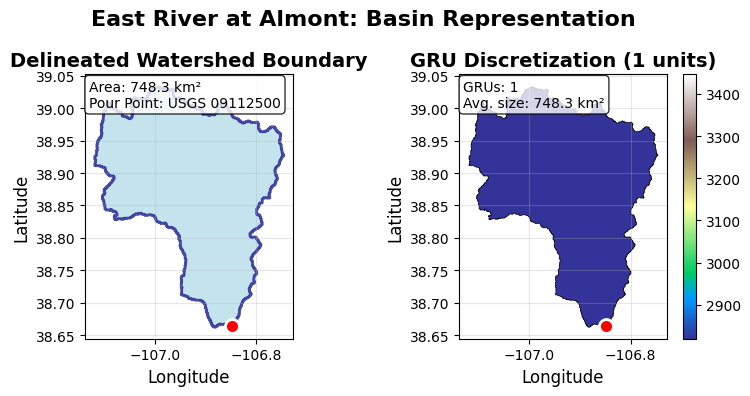

In [10]:
# Load spatial data
hru_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'shapefiles' / 'catchment' / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp")
watershed_gdf = gpd.read_file(str(watershed_path[1]))
hru_gdf = gpd.read_file(hru_path)
pour_point_gdf = gpd.read_file(pour_point_path)

# Project to appropriate CRS for area calculations
# For East River at Almont,, UTM Zone 13N is appropriate
target_crs = 'EPSG:32613'  # UTM Zone 13N
watershed_projected = watershed_gdf.to_crs(target_crs)
hru_projected = hru_gdf.to_crs(target_crs)

print(f"\n📋 Basin Characteristics:")
total_area_m2 = watershed_projected.geometry.area.sum()
total_area_km2 = total_area_m2 / 1e6
print(f"   Watershed area: {total_area_km2:.1f} km²")
print(f"   Number of GRUs: {len(hru_gdf)}")
print(f"   Average GRU size: {total_area_km2/len(hru_gdf):.1f} km²")

# Display HRU characteristics if available
if 'elevation' in hru_gdf.columns:
    print(f"   Elevation range: {hru_gdf['elevation'].min():.0f}m to {hru_gdf['elevation'].max():.0f}m")
if 'slope' in hru_gdf.columns:
    print(f"   Slope range: {hru_gdf['slope'].min():.1f}° to {hru_gdf['slope'].max():.1f}°")

# Create comprehensive visualization
print(f"\n🗺️  Creating basin representation visualization...")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left plot: Watershed boundary and pour point (use original CRS for plotting)
ax1 = axes[0]
watershed_gdf.plot(ax=ax1, facecolor='lightblue', edgecolor='navy', 
                  linewidth=2, alpha=0.7)
pour_point_gdf.plot(ax=ax1, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax1.set_title('Delineated Watershed Boundary', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add area annotation
ax1.text(0.02, 0.98, f'Area: {total_area_km2:.1f} km²\nPour Point: USGS {config_dict["STATION_ID"]}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

# Right plot: HRU discretization
ax2 = axes[1]
# Color HRUs by elevation if available, otherwise by area (using projected areas)
if 'elev_mean' in hru_gdf.columns:
    hru_gdf.plot(ax=ax2, column='elev_mean', cmap='terrain', 
                edgecolor='black', linewidth=0.5, legend=True)
    colorbar_label = 'Elevation (m)'
else:
    # Use projected geometries for area calculation
    hru_areas_km2 = hru_projected.geometry.area / 1e6
    hru_gdf.plot(ax=ax2, column=hru_areas_km2, cmap='viridis',
                edgecolor='black', linewidth=0.5, legend=True) 
    colorbar_label = 'Area (km²)'

pour_point_gdf.plot(ax=ax2, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax2.set_title(f'GRU Discretization ({len(hru_gdf)} units)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add discretization info
ax2.text(0.02, 0.98, f'GRUs: {len(hru_gdf)}\nAvg. size: {total_area_km2/len(hru_gdf):.1f} km²',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

plt.suptitle(f'East River at Almont: Basin Representation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Data Pipeline for Basin-Scale Streamflow Modeling
The same model-agnostic preprocessing framework now scales from point validation to basin-scale streamflow simulation. The core philosophy remains unchanged—standardized, quality-controlled data products—but the spatial context shifts from single locations to integrated watershed responses

In [11]:
# =============================================================================
# FORCING DATA PROCESSOR - Using reusable module
# =============================================================================
from utils.custom.forcing_processor import ForcingProcessor

# Initialize the forcing processor with config
forcing_processor = ForcingProcessor(config_dict)

# Check current status of forcing data
status = forcing_processor.check_status()

FORCING DATA STATUS

Required period: 2007-10 to 2016-09
Required months: 108

📁 Raw ERA5 surface files: 501
📁 Raw ERA5 pressure files: 501

📁 Merged files: 501
   Range: 198101 to 202209

📁 Basin-averaged files: 501
   Range: 198101 to 202209

📁 SUMMA input files: 501
   Range: 198101 to 202209

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 0


In [12]:
# =============================================================================
# STEP 3a: MERGE RAW ERA5 DATA (Surface + Pressure Level)
# =============================================================================
# Combines ERA5_surface_YYYYMM.nc + ERA5_pressureLevel137_YYYYMM.nc into ERA5_merged_YYYYMM.nc

forcing_processor.merge_era5()

✅ All merged files already exist


0

In [13]:
# =============================================================================
# STEP 3b: BASIN-AVERAGE MERGED DATA OVER CATCHMENT
# =============================================================================
# Uses CONFLUENCE's built-in EASYMORE resampler for spatial averaging
forcing_processor.basin_average(confluence=confluence)

✅ All basin-averaged files already exist


0

In [14]:
# =============================================================================
# STEP 3c: CREATE SUMMA INPUT (with optional adjustments)
# =============================================================================
# Optional: apply temperature offset and/or precipitation scaling

forcing_processor.create_summa_input(
    temp_adjustment=0.0,      # Kelvin offset (0 = no change)
    precip_multiplier=1.0,     # Scaling factor (1.0 = no change)
    recalc_longwave=True
)

# Verify final status
forcing_processor.check_status()

✅ All SUMMA input files already exist
FORCING DATA STATUS

Required period: 2007-10 to 2016-09
Required months: 108

📁 Raw ERA5 surface files: 501
📁 Raw ERA5 pressure files: 501

📁 Merged files: 501
   Range: 198101 to 202209

📁 Basin-averaged files: 501
   Range: 198101 to 202209

📁 SUMMA input files: 501
   Range: 198101 to 202209

⚠️  Missing merged: 0
⚠️  Missing basin-averaged: 0
⚠️  Missing SUMMA input: 0


{'required_period': '2007-10 to 2016-09',
 'required_months': 108,
 'raw_surface_count': 501,
 'raw_pressure_count': 501,
 'merged_count': 501,
 'basin_avg_count': 501,
 'summa_input_count': 501,
 'missing_merged': [],
 'missing_basin_avg': [],
 'missing_summa': []}

### Observed data

In [15]:
# Execute streamflow data processing
confluence.managers['data'].process_observed_data()
print("✅ Streamflow data processing complete")

2026-03-24 12:32:51 ● Processing observed data
2026-03-24 12:32:51 ● Processing USGS streamflow data directly from API
2026-03-24 12:32:51 ● Retrieving discharge data for station 09112500
2026-03-24 12:32:51 ● Time period: 2007-10-01 to 2026-03-23
2026-03-24 12:32:51 ● Converting from cfs to cms using factor: 0.0283168
2026-03-24 12:32:51 ● Using formatted start date: 2007-10-01
2026-03-24 12:32:51 ● Using formatted end date: 2026-03-23
2026-03-24 12:32:51 ● Fetching data from: https://nwis.waterservices.usgs.gov/nwis/dv/?site=09112500&format=rdb&parameterCd=00060&startDT=2007-10-01&endDT=2026-03-23


2026-03-24 12:32:51 ● Using discharge column: 18852_00060_00003
2026-03-24 12:32:51 ● Using datetime column: datetime
2026-03-24 12:32:51 ● Dropping 77 rows with non-numeric discharge values
2026-03-24 12:32:53 ● Processed streamflow data saved to: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/streamflow/preprocessed/East_River_lumped_streamflow_processed.csv
2026-03-24 12:32:53 ● Total rows in processed data: 161953
2026-03-24 12:32:53 ● Number of non-null values: 160107
2026-03-24 12:32:53 ● Number of null values: 1846
2026-03-24 12:32:53 ● Successfully processed USGS data for station 09112500
2026-03-24 12:32:53 ● Retrieved 6672 records from 2007-10-01 00:00:00 to 2026-03-23 00:00:00
2026-03-24 12:32:53 ● Processing SNOTEL data
2026-03-24 12:32:53 ● SNOTEL data processing is disabled in configuration
2026-03-24 12:32:53 ● Processing FLUXNET data
2026-03-24 12:32:53 ● FLUXNET data processing is disabled in configuration
2026-03-24 12:32:53 ● Processing USGS 

### Model Agnostic preprocessing

In [16]:
# Execute model-agnostic preprocessing
confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Model-agnostic preprocessing complete")

2026-03-24 12:32:53 ● Starting model-agnostic preprocessing
2026-03-24 12:32:53 ● Running geospatial statistics
2026-03-24 12:32:53 ● Starting geospatial statistics calculation
2026-03-24 12:32:53 ● Soil statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
2026-03-24 12:32:53 ● Land statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
2026-03-24 12:32:53 ● Elevation statistics already calculated: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment_intersection/with_dem/catchment_with_dem.shp
2026-03-24 12:32:53 ● Geospatial statistics completed: 3/3 steps skipped, 0/3 steps executed
2026-03-24 12:32:53 ● Running forcing resampling
2026-03-24 12:32:53 ● Starting forcing data resampling process
2026-03-24 12:32:53 ● Creating ERA5 shap

In [17]:
# =============================================================================
# PROTECT CUSTOM PARAMETER FILES BEFORE PREPROCESSING
# =============================================================================
# IMPORTANT: Backup custom parameter files before model preprocessing,
# because confluence.managers['model'].preprocess_models() calls
# copy_base_settings() which would overwrite our custom configurations!

print("🔒 Backing up custom parameter files before preprocessing...")
project_settings_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / "settings" / "SUMMA"
backup_dir = project_settings_dir / "backup_custom_config"
backup_dir.mkdir(parents=True, exist_ok=True)

# Backup the three critical parameter files
critical_files = [
    "modelDecisions.txt",
    "localParamInfo.txt", 
    "basinParamInfo.txt"
]

for fname in critical_files:
    src = project_settings_dir / fname
    dst = backup_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Backed up {fname}")
    else:
        print(f"   ⚠ {fname} not found (will be created during preprocessing)")

# ============= Execute model-specific preprocessing =============
# This step will copy base settings and create forcing files, initial conditions, etc.
# But it WILL overwrite our custom parameter files, so we backed them up above!
confluence.managers['model'].preprocess_models()
print("✅ Model-specific preprocessing complete")

# ============= RESTORE CUSTOM PARAMETER FILES AFTER PREPROCESSING =============
print("\n🔓 Restoring custom parameter files after preprocessing...")
for fname in critical_files:
    src = backup_dir / fname
    dst = project_settings_dir / fname
    if src.exists():
        shutil.copy(src, dst)
        print(f"   ✓ Restored {fname}")

print(f"\n✓ Custom parameters protected and restored in {project_settings_dir}")
print(f"✓ Base settings remain unchanged in {base_settings_dir}")

🔒 Backing up custom parameter files before preprocessing...
   ✓ Backed up modelDecisions.txt
   ✓ Backed up localParamInfo.txt
   ✓ Backed up basinParamInfo.txt
2026-03-24 12:32:58 ● Starting model-specific preprocessing
2026-03-24 12:32:58 ● Starting SUMMA spatial preprocessing
2026-03-24 12:32:58 ● Starting memory-efficient temperature lapse rate and data step application
2026-03-24 12:32:58 ● Loading topology data...
2026-03-24 12:32:58 ● Loaded topology data: 25 rows, 0.02 MB
2026-03-24 12:32:58 ● Found 501 forcing files to process
2026-03-24 12:32:58 ● Pre-calculating lapse rate corrections...
2026-03-24 12:32:58 ● Prepared lapse corrections for 1 HRUs
2026-03-24 12:32:58 ● Processing files in batches of 100


2026-03-24 12:33:45 ● Completed processing of 501 ERA5 forcing files with temperature lapsing
2026-03-24 12:33:45 ● Copying SUMMA base settings
2026-03-24 12:33:45 ● SUMMA base settings copied to /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA
2026-03-24 12:33:45 ● Creating SUMMA file manager
2026-03-24 12:33:45 ● SUMMA file manager created at /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/fileManager.txt
2026-03-24 12:33:45 ● Creating forcing file list
2026-03-24 12:33:45 ● Found 501 ERA5 forcing files
2026-03-24 12:33:45 ● Forcing file list created at /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/forcingFileList.txt with 501 files
2026-03-24 12:33:45 ● Creating initial conditions (cold state) file
2026-03-24 12:33:45 ● Creating initial conditions (cold state) file
2026-03-24 12:33:45 ● Initial conditions file created at: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/coldState_

#### No longer really needed.
This is the manual update to the forcing files

In [18]:
# open the dem 
dem_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'attributes' / 'elevation' / "dem" / "domain_East_River_lumped_elv.tif")

# using rasterio open the dem
import rasterio
with rasterio.open(dem_path) as dem_src:
    dem_data = dem_src.read(1)  # Read the first band
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

# calculate the mean elevation
mean_elevation = np.nanmean(dem_data)

# adjust temperature by difference between mean dem elevation and mean hru elevation
mean_hru_elevation = hru_gdf['elev_mean'].mean()
elevation_difference = mean_hru_elevation - mean_elevation
lapse_rate = 6.5 / 1000  # °C per meter
temperature_adjustment = elevation_difference * lapse_rate

# winter adjustment (Jan - May)
monthly_adjustment = {
    1: 1.0,  # January
    2: 1.0,  # February
    3: 1.0,  # March
    4: 1.0,  # April
    5: 1.0,  # May
    6: 0.0,  # June
    7: -1.0,  # July
    8: -1.0,  # August
    9: -1.0,  # September
    10: -1.0, # October
    11: -1.0, # November
    12: 0.0  # December
}

In [19]:
file_list = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(f"domain_{config_dict['DOMAIN_NAME']}/forcing/forcing_noTadjust/{config_dict['DOMAIN_NAME']}_ERA5_remapped_ERA5_merged_*.nc"))
file_list = sorted(file_list)
for file in file_list:
    ds = xr.open_dataset(str(file))
    # adjust temperature
    ds['airtemp'] = ds['airtemp'] #+ temperature_adjustment
    # determe additional monthly temperature adjustment
    # monthlyTempAdjustment = monthly_adjustment[ds['airtemp'].time.dt.month.values[0]]
    # ds['airtemp'] = ds['airtemp'] + monthlyTempAdjustment
    # adjust precipitation
    # ds['pptrate'] = ds['pptrate'] * 0.90  # Example: decrease precipitation by 10%
    # recalculate incoming longwave radiation using empirical formula
    ds['LWRadAtm'] = empirical_lw_dilley_obrien(ds['airtemp'], ds['spechum'], ds['airpres'])
    # save the modified dataset back to new file
    adjusted_file_path = str(file).replace("forcing_noTadjust", "SUMMA_input")
    ds.to_netcdf(adjusted_file_path)
    ds.close()

## Step 4: Streamlined Basin-Scale Model Execution
The same SUMMA process-based physics now scales from point validation to integrated basin simulation, but with the critical addition of streamflow routing. This represents a fundamental modeling advancement: from isolated vertical processes to coupled vertical-horizontal water transport that generates streamflow at the basin outlet.

In [20]:
# =============================================================================
# NOW RUN THE MODEL
# =============================================================================

print("\n" + "="*60)
print("🚀 Running SUMMA model...")
print("="*60)

confluence.managers['model'].run_models()
print("✅ Basin-scale integrated simulation complete")


🚀 Running SUMMA model...
2026-03-24 12:33:45 ● Starting model runs
2026-03-24 12:33:45 ● Running model: SUMMA
2026-03-24 12:33:45 ● Starting SUMMA run


2026-03-24 12:34:59 ● SUMMA run completed successfully
✅ Basin-scale integrated simulation complete


## Step 5: Streamflow Evaluation and Basin Performance Assessment

/tmp/ipykernel_136443/3523471680.py:97: RuntimeWarning: invalid value encountered in scalar divide
  obs_com = np.sum(days * obs_vals) / np.sum(obs_vals)



=== TIMING DIAGNOSTICS ===
Mean timing offset: 20 days (negative = early)
Peak month: Obs=6, Sim=6
NSE (post spin-up): -2.656


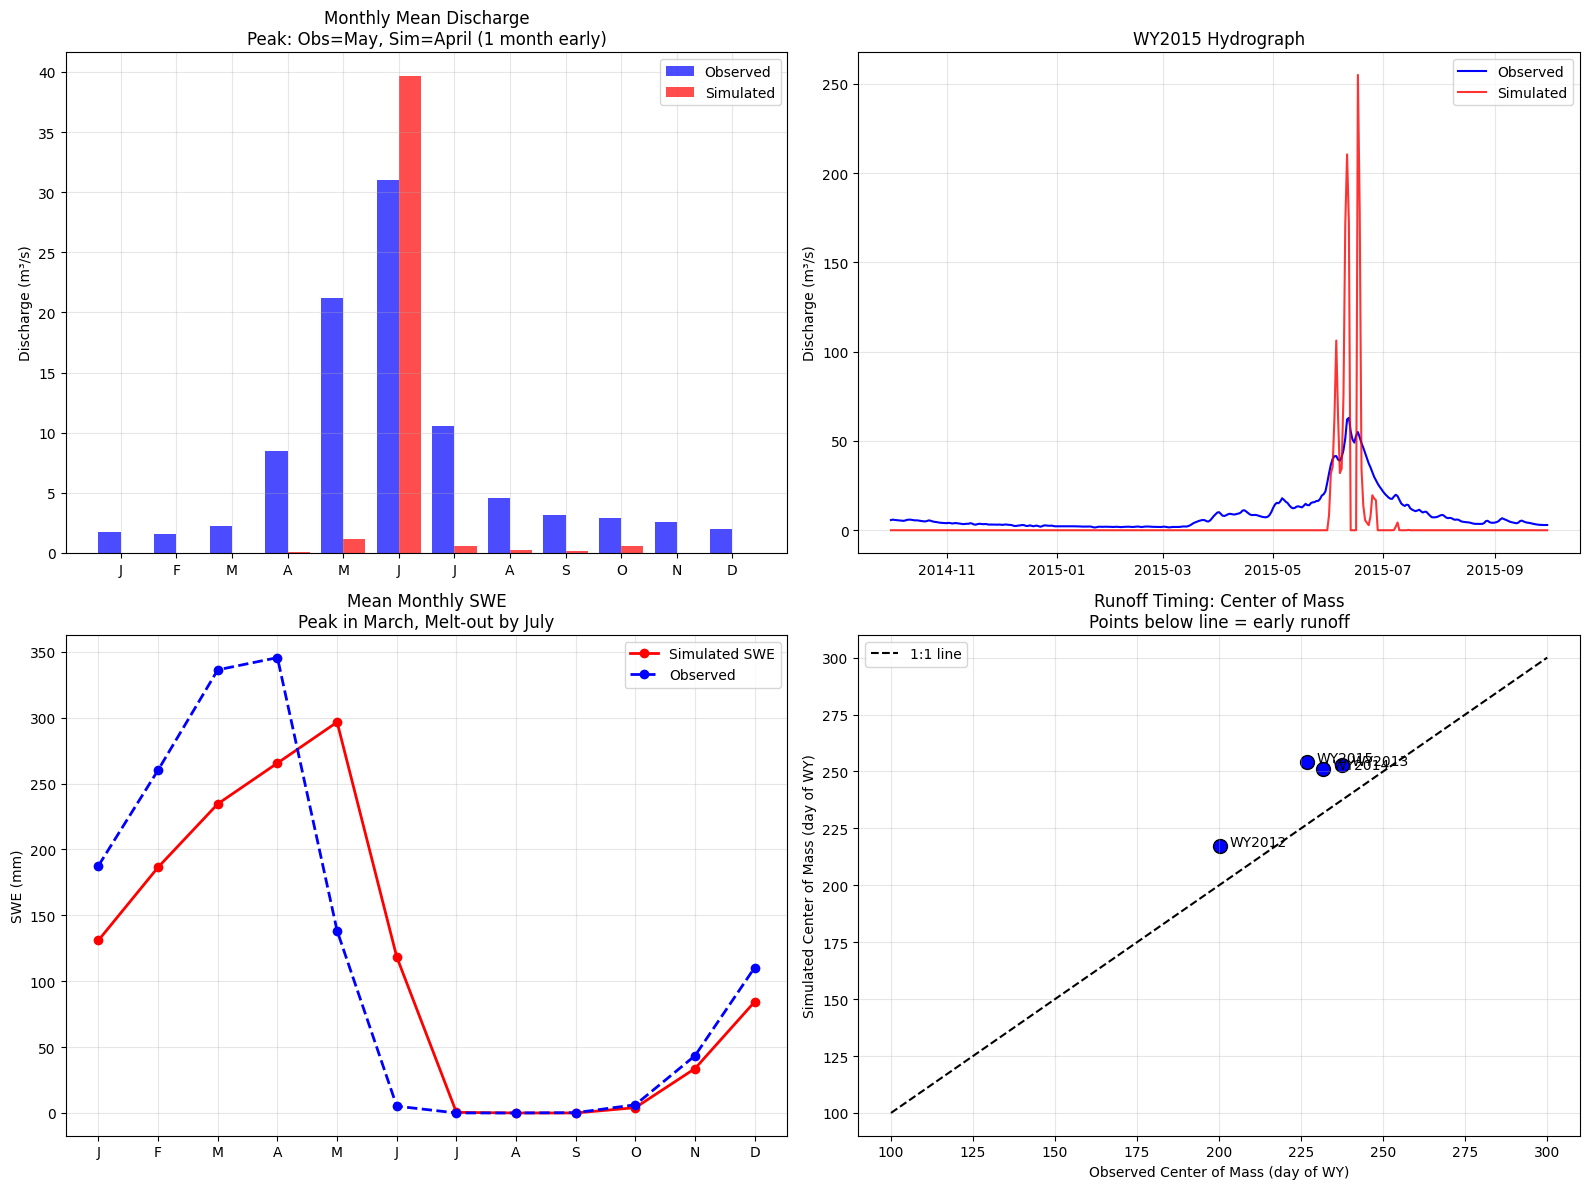

In [21]:
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
save = False

# Get basin area
shp_path = project_dir / "shapefiles" / "catchment" / "East_River_lumped_HRUs_GRUs.shp"
gdf = gpd.read_file(shp_path).to_crs('EPSG:32611')
basin_area = gdf.geometry.area.sum()

# Calculate discharge
runoff = sim_ds['scalarTotalRunoff'].squeeze()
discharge = runoff * basin_area  # m³/s

# Load observations
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / "East_River_lumped_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)

# Align to common period (skip first year for spin-up)
start = '2011-10-01'
end = '2022-09-30'
sim_daily = discharge.resample(time='D').mean().sel(time=slice(start, end))
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start:end]

# Create figure
fig = plt.figure(figsize=(16, 12))

# 1. Monthly climatology comparison
ax1 = fig.add_subplot(2, 2, 1)
sim_monthly = sim_daily.groupby('time.month').mean()
obs_monthly = obs_daily.groupby(obs_daily.index.month).mean()
months = range(1, 13)
ax1.bar([m-0.2 for m in months], [float(obs_monthly.loc[m]) for m in months], 
        width=0.4, label='Observed', color='blue', alpha=0.7)
ax1.bar([m+0.2 for m in months], [float(sim_monthly.sel(month=m)) for m in months], 
        width=0.4, label='Simulated', color='red', alpha=0.7)
ax1.set_xticks(months)
ax1.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax1.set_ylabel('Discharge (m³/s)')
ax1.set_title('Monthly Mean Discharge\nPeak: Obs=May, Sim=April (1 month early)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Water year 2015 hydrograph
ax2 = fig.add_subplot(2, 2, 2)
wy2015_sim = sim_daily.sel(time=slice('2014-10-01', '2015-09-30'))
wy2015_obs = obs_daily.loc['2014-10-01':'2015-09-30']
ax2.plot(wy2015_obs.index, wy2015_obs.values, 'b-', label='Observed', lw=1.5)
ax2.plot(pd.to_datetime(wy2015_sim.time.values), wy2015_sim.values, 'r-', label='Simulated', lw=1.5, alpha=0.8)
ax2.set_ylabel('Discharge (m³/s)')
ax2.set_title('WY2015 Hydrograph')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. SWE comparison with East  if available
ax3 = fig.add_subplot(2, 2, 3)
swe = sim_ds['scalarSWE'].squeeze().resample(time='D').mean()
tuolumne_meadows = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/snow/380_Butte_sntl_obs.csv", parse_dates=['datetime'], index_col='datetime')
tuolumne_meadows_swe = tuolumne_meadows['SWE']*25.4
# filter values 
# filter extreme values
tuolumne_meadows_swe = tuolumne_meadows_swe[(tuolumne_meadows_swe < 2000) & (tuolumne_meadows_swe >= 0)]
tuolumne_meadows_swe_monthly = tuolumne_meadows_swe.groupby(tuolumne_meadows_swe.index.month).mean()
# Plot multi-year average SWE cycle
swe_monthly = swe.sel(time=slice(start, end)).groupby('time.month').mean()
ax3.plot(months, [float(swe_monthly.sel(month=m)) for m in months], 'r-o', lw=2, label='Simulated SWE')
ax3.plot(months, tuolumne_meadows_swe_monthly.values, 'b--o', lw=2, label='Observed')
ax3.set_xticks(months)
ax3.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax3.set_ylabel('SWE (mm)')
ax3.set_title('Mean Monthly SWE\nPeak in March, Melt-out by July')
ax3.grid(True, alpha=0.3)
ax3.legend()

# 4. Timing metrics by year
ax4 = fig.add_subplot(2, 2, 4)
timing_data = []
for year in range(2011, 2016):
    wy_start = f'{year-1}-10-01'
    wy_end = f'{year}-09-30'
    
    sim_wy = sim_daily.sel(time=slice(wy_start, wy_end))
    obs_wy = obs_daily.loc[wy_start:wy_end]
    
    # for obs interpolate missing data
    obs_wy = obs_wy.interpolate(method='time', limit_direction='both')
    # Find center of mass (timing metric)
    sim_vals = sim_wy.values
    obs_vals = obs_wy.values
    
    days = np.arange(len(sim_vals))
    if np.sum(sim_vals) > 0:
        sim_com = np.sum(days * sim_vals) / np.sum(sim_vals)
    else:
        sim_com = np.nan
        
    obs_com = np.sum(days * obs_vals) / np.sum(obs_vals)
    
    timing_data.append({'year': year, 'sim_com': sim_com, 'obs_com': obs_com})

timing_df = pd.DataFrame(timing_data)
ax4.scatter(timing_df['obs_com'], timing_df['sim_com'], s=100, c='blue', edgecolor='black')
ax4.plot([100, 300], [100, 300], 'k--', label='1:1 line')
for _, row in timing_df.iterrows():
    ax4.annotate(f"WY{int(row['year'])}", (row['obs_com']+3, row['sim_com']))
ax4.set_xlabel('Observed Center of Mass (day of WY)')
ax4.set_ylabel('Simulated Center of Mass (day of WY)')
ax4.set_title('Runoff Timing: Center of Mass\nPoints below line = early runoff')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
if save:
    plt.savefig('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/plots/timing_diagnostic.png', dpi=150)
    print("Saved: timing_diagnostic.png")

# Print summary statistics
print("\n=== TIMING DIAGNOSTICS ===")
print(f"Mean timing offset: {float(timing_df['sim_com'].mean() - timing_df['obs_com'].mean()):.0f} days (negative = early)")
print(f"Peak month: Obs={obs_monthly.idxmax()}, Sim={int(sim_monthly.argmax())+1}")

# Calculate NSE excluding spin-up
common_idx = pd.to_datetime(sim_daily.time.values)
obs_aligned = obs_daily.reindex(common_idx)
valid = ~obs_aligned.isna()
sim_v = sim_daily.values[valid]
obs_v = obs_aligned.values[valid]
nse = 1 - np.sum((obs_v - sim_v)**2) / np.sum((obs_v - np.mean(obs_v))**2)
print(f"NSE (post spin-up): {nse:.3f}")

sim_ds.close()
plt.show()

In [34]:
from utils.custom import linear_reservoir

results = linear_reservoir.calibrate_reservoirs(q_in=discharge.sel(time=slice("2005-10-01","2015-10-01")).resample(time='1D').mean().values, 
                               obs=obs_df['discharge_cms'].loc['2005-10-01':'2015-10-01'].resample('1D').mean().values, metric='nse')

print(f"k_fast : {results['k_fast']:.4f} day-1  "
      f"({results['residence_fast_days']:.1f} day residence time)")
print(f"k_slow : {results['k_slow']:.4f} day-1  "
      f"({results['residence_slow_days']:.1f} day residence time)")
print(f"f_fast : {results['f_fast']:.2f}")
print(f"NSE    : {results['nse']:.3f}")
print(f"KGE    : {results['kge']:.3f}")
print(f"logNSE : {results['log_nse']:.3f}")

k_fast : 1.0000 day-1  (1.0 day residence time)
k_slow : 0.0466 day-1  (21.5 day residence time)
f_fast : 0.12
NSE    : 0.331
KGE    : 0.323
logNSE : -13.796


In [35]:
df_routed = pd.DataFrame({
    'time': obs_df['discharge_cms'].loc['2005-10-01':'2015-10-01'].resample('1D').mean().index,
    'routed_discharge': results['sim'],
    'observed': obs_df['discharge_cms'].loc['2005-10-01':'2015-10-01'].resample('1D').mean(),
}).set_index('time')

<Axes: xlabel='time'>

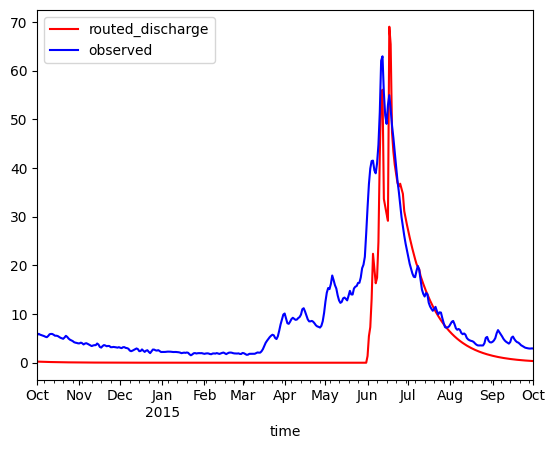

In [36]:
fig, ax = plt.subplots()
df_routed.loc['2014-10-01':'2015-10-01'].plot(y=['routed_discharge', 'observed'], ax=ax, color=['red', 'blue'])


 Streamflow Performance Assessment...
   Evaluation period: 2008-04-01 00:00:00 to 2016-09-30 23:00:00.000013312
   Duration: 3104 days
   Valid paired observations: 102 days

📈 Streamflow Performance Metrics:
   📊 RMSE: 10.35 m³/s
   📊 Bias: -4.83 m³/s (-51.8%)
   📊 MAE: 6.75 m³/s
   📊 Correlation (r): 0.783
   📊 Nash-Sutcliffe (NSE): 0.343
   📊 Kling-Gupta (KGE): 0.421

🌊 Hydrologic Signature Analysis:
   High flows (Q95): Obs=37.8, Sim=36.6 m³/s
   Low flows (Q05): Obs=1.5, Sim=0.0 m³/s
   Peak flow timing: Obs=Month 6, Sim=Month hru
1    6
dtype: int32


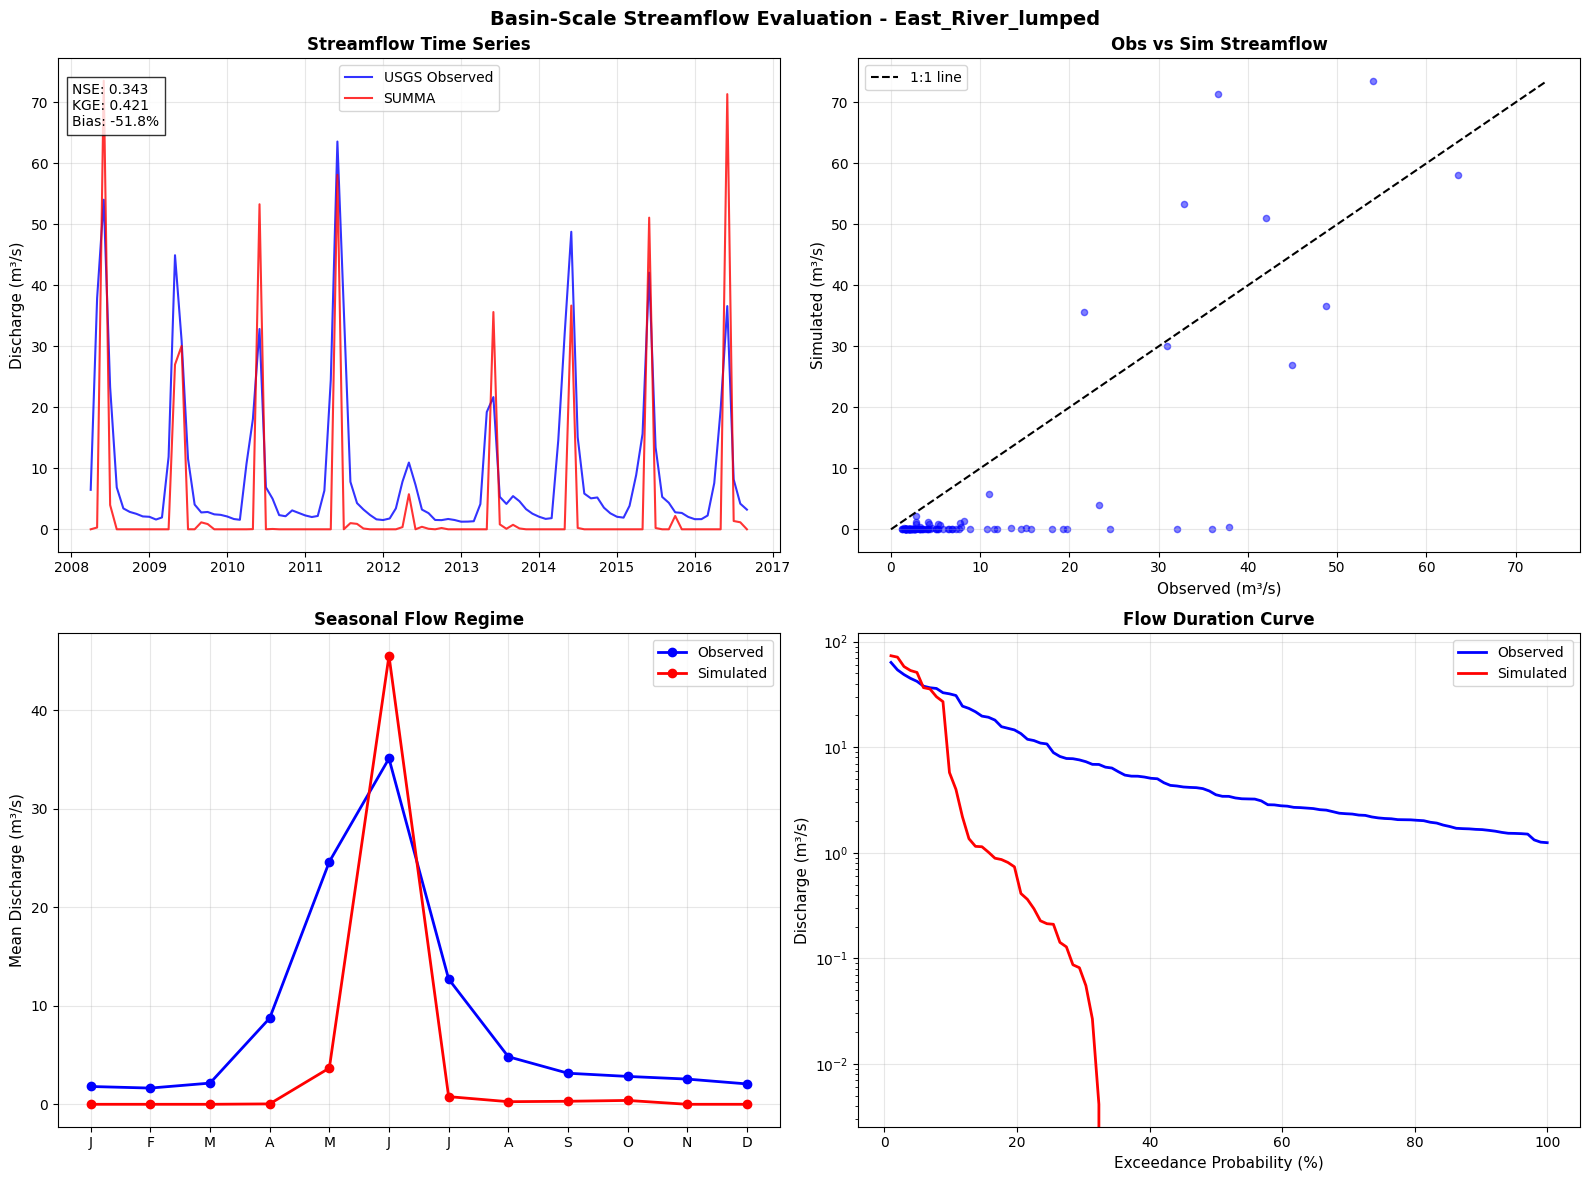

In [25]:
# Load observed streamflow data
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)
    
# Load simulated streamflow from mizuRoute
routing_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))

if routing_files:
    # Load mizuRoute output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract streamflow variable (typically IRFroutedRunoff)
    
    sim_streamflow = routing_ds['IRFroutedRunoff']
    sim_df = sim_streamflow.to_pandas()    
    routing_ds.close()

else:
    sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
    shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    shp_area = shp_file['GRU_area'].values[0]
    sim_ds['scalarTotalRunoff'] = sim_ds['scalarTotalRunoff'] * shp_area
    sim_streamflow = sim_ds['scalarTotalRunoff']    
    sim_df = sim_streamflow.to_pandas()
    # Calculate discharge
    
    sim_ds.close()

# =============================================================================
# STREAMFLOW PERFORMANCE EVALUATION
# =============================================================================

print(f"\n Streamflow Performance Assessment...")

# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

print(f"   Evaluation period: {start_date} to {end_date}")
print(f"   Duration: {(end_date - start_date).days} days")

# Filter to common period and resample to daily
obs_daily = obs_df['discharge_cms'].resample('MS').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('MS').mean().loc[start_date:end_date]

# Ensure sim_daily is a Series (in case it's a DataFrame with one column)
if isinstance(sim_daily, pd.DataFrame):
    if sim_daily.shape[1] == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Take the first (and likely only) column
    else:
        print(f"⚠️  sim_daily has {sim_daily.shape[1]} columns. Using the first column.")
        print(f"   Available columns: {list(sim_daily.columns)}")
        sim_daily = sim_daily.iloc[:, 0]

# Remove any remaining NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]    
print(f"   Valid paired observations: {len(obs_valid)} days")

# Calculate comprehensive performance metrics
print(f"\n📈 Streamflow Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()

# Relative metrics
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency  
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# Hydrologic signature analysis
print(f"\n🌊 Hydrologic Signature Analysis:")

# Flow statistics
obs_q95 = obs_valid.quantile(0.95)  # High flows
sim_q95 = sim_valid.quantile(0.95)
obs_q05 = obs_valid.quantile(0.05)  # Low flows  
sim_q05 = sim_valid.quantile(0.05)

print(f"   High flows (Q95): Obs={obs_q95:.1f}, Sim={sim_q95:.1f} m³/s")
print(f"   Low flows (Q05): Obs={obs_q05:.1f}, Sim={sim_q05:.1f} m³/s")

# Seasonal timing
obs_monthly = obs_df['discharge_cms'].resample('MS').mean()
sim_monthly = sim_df.resample('MS').mean()
obs_monthly = obs_monthly.groupby(obs_monthly.index.month).mean()
sim_monthly = sim_monthly.groupby(sim_monthly.index.month).mean()
peak_month_obs = obs_monthly.idxmax()
peak_month_sim = sim_monthly.idxmax()

print(f"   Peak flow timing: Obs=Month {peak_month_obs}, Sim=Month {peak_month_sim}")

# =============================================================================
# STREAMFLOW VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-', 
         label='USGS Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-', 
         label='SUMMA', linewidth=1.5, alpha=0.8)


ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Streamflow Time Series', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim Streamflow', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

ax3.plot(months, obs_monthly.values, 'o-', label='Observed', 
         color='blue', linewidth=2, markersize=6)
ax3.plot(months, sim_monthly.values, 'o-', label='Simulated', 
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Simulated', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Basin-Scale Streamflow Evaluation - {config_dict["DOMAIN_NAME"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Water Balance Components

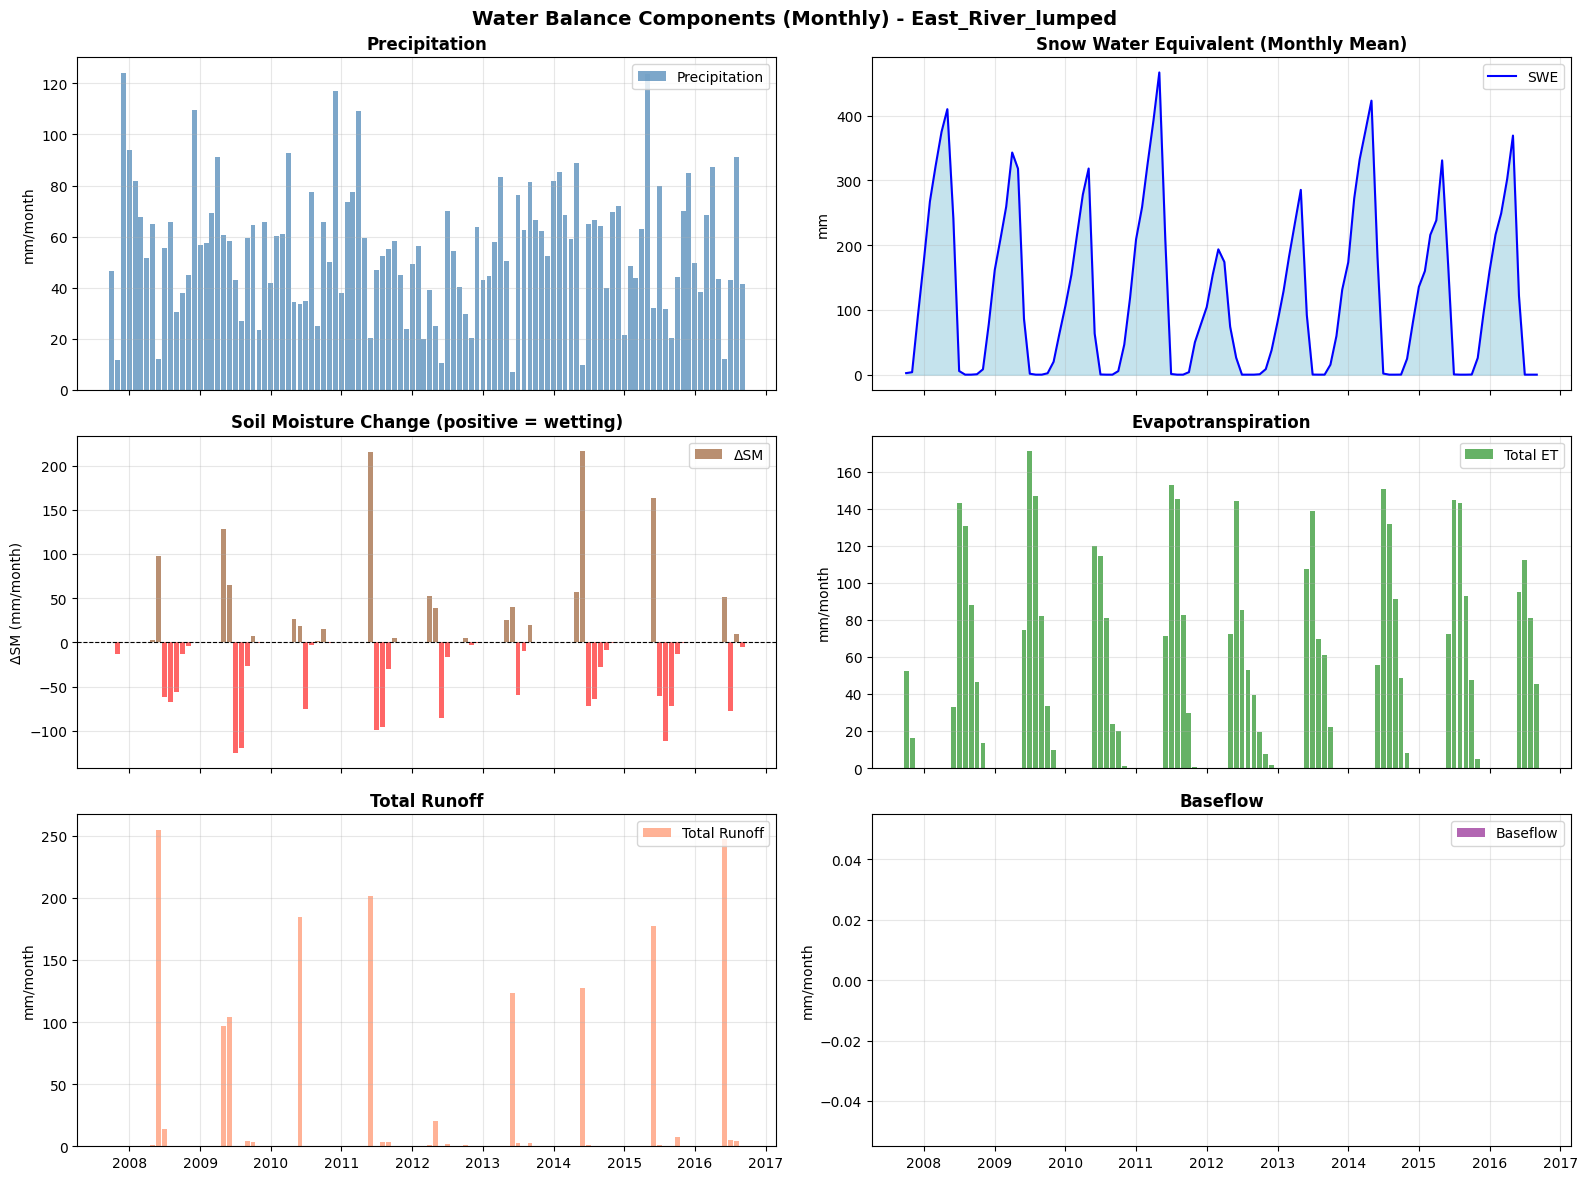

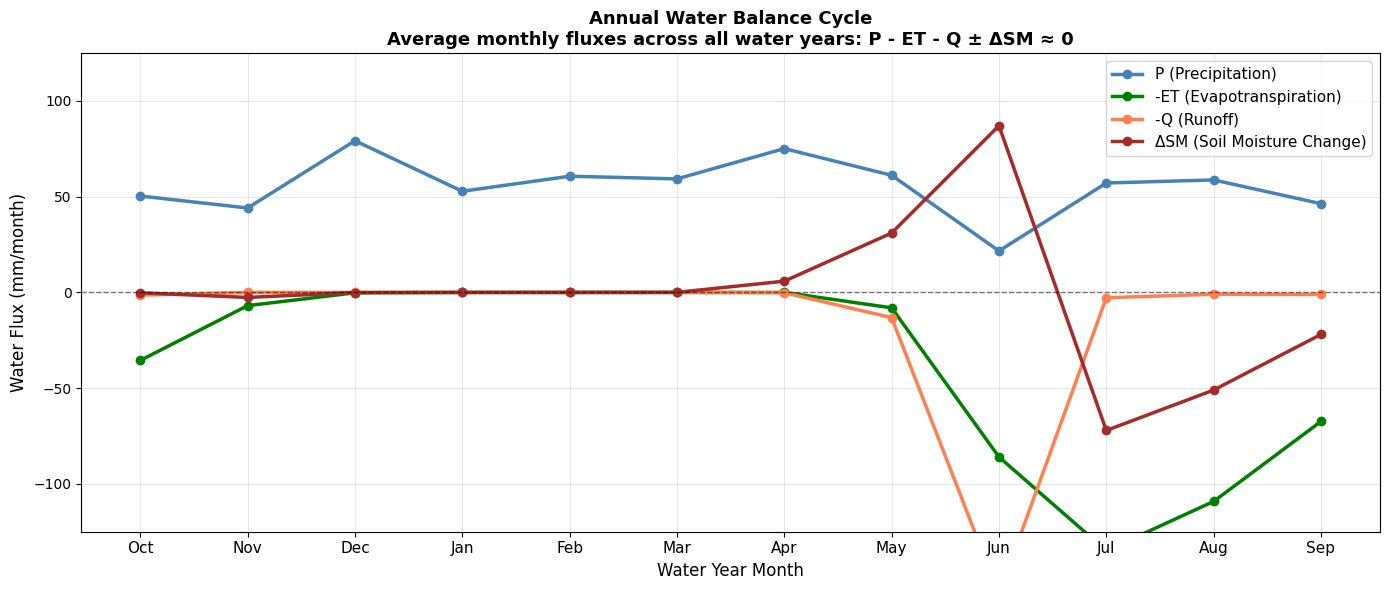


ANNUAL WATER BALANCE SUMMARY (mm/year)
Water Year     P (mm)     ET (mm)     Q (mm)   ΔSM (mm)
    WY2002   0.000000    0.000000   0.000000   0.000000
    WY2003   0.000000    0.000000   0.000000   0.000000
    WY2004   0.000000    0.000000   0.000000   0.000000
    WY2005   0.000000    0.000000   0.000000   0.000000
    WY2006   0.000000    0.000000   0.000000   0.000000
    WY2007   0.000000    0.000000   0.000000   0.000000
    WY2008 705.043895 -463.979146 270.059555 -97.623728
    WY2009 714.932183 -534.804659 204.801048 -94.345993
    WY2010 614.918895 -382.434708 187.987521 -26.429355
    WY2011 765.670948 -473.025292 208.028742   5.102782
    WY2012 491.830884 -424.990002  24.096610  -3.731868
    WY2013 620.077944 -405.908263 129.891113  17.747182
    WY2014 769.608310 -451.674751 128.391365 109.676554
    WY2015 645.737569 -509.888196 177.757553 -89.779260
    WY2016 673.697740 -386.422378 263.957406 -35.283767
    WY2017   0.000000    0.000000   0.000000   0.000000
    WY20

In [26]:
# =============================================================================
# WATER BALANCE COMPONENT TIMESERIES - MONTHLY TOTALS
# =============================================================================
import matplotlib.dates as mdates

# Load SUMMA output for water balance analysis
summa_file = list(summa_dir.glob("*.nc"))
if summa_file:
    ds_wb = xr.open_dataset(summa_file[0])
    ds_wb = ds_wb.sel(time=slice('2001-10-01', '2022-09-30'))  # Focus on common period
    
    # Extract time and convert to pandas datetime
    time_wb = pd.to_datetime(ds_wb['time'].values)
    
    # Initialize monthly series
    monthly_precip = None
    monthly_swe = None
    monthly_delta_sm = None
    monthly_et = None
    monthly_runoff = None
    monthly_baseflow = None
    
    # 1. Precipitation (convert from kg/m2/s to mm/month via daily totals)
    if 'pptrate' in ds_wb:
        precip = ds_wb['pptrate'].values.squeeze() * 86400 / 24  # kg/m2/s to mm/day
        precip_daily = pd.Series(precip, index=time_wb)
        monthly_precip = precip_daily.resample('MS').sum()  # Monthly total
    
    # 2. SWE (keep as daily mean for end-of-month values, kg/m2 = mm)
    if 'scalarSWE' in ds_wb:
        swe_wb = ds_wb['scalarSWE'].values.squeeze()
        swe_daily = pd.Series(swe_wb, index=time_wb)
        monthly_swe = swe_daily.resample('MS').mean()  # Monthly mean for visualization
    
    # 3. Soil Moisture Change (Delta SM in mm/month)
    if 'scalarTotalSoilLiq' in ds_wb:
        soil_total = (ds_wb['scalarTotalSoilLiq'] + 
              ds_wb['scalarTotalSoilIce']).values.squeeze()
        soil_series = pd.Series(soil_total, index=time_wb)
        # Monthly ΔS: last value of month minus last value of prior month
        monthly_delta_sm = soil_series.resample('MS').last().diff()
            
    # 4. Evapotranspiration (convert from W/m2 to mm/month)
    latent_heat_vap = 2.45e6  # J/kg
    if 'scalarTotalET' in ds_wb:
        et_wm2 = ds_wb['scalarTotalET'].values.squeeze()  # W m-2
        et_mm_day = et_wm2 * 86400 / 24
        et_daily = pd.Series(et_mm_day, index=time_wb)
        monthly_et = et_daily.resample('MS').sum()  # Monthly total
    
    # 5. Runoff (convert from m/s to mm/month)
    if 'scalarTotalRunoff' in ds_wb:
        runoff_wb = ds_wb['scalarTotalRunoff'].values.squeeze() * 86400 / 24 * 1000  # m/s to mm/day
        runoff_daily = pd.Series(runoff_wb, index=time_wb)
        monthly_runoff = runoff_daily.resample('MS').sum()  # Monthly total
    
    # 6. Aquifer/Baseflow (convert from m/s to mm/month)
    if 'scalarAquiferBaseflow' in ds_wb:
        baseflow = ds_wb['scalarAquiferBaseflow'].values.squeeze() * 86400 / 24 * 1000  # m/s to mm/day
        baseflow_daily = pd.Series(baseflow, index=time_wb)
        monthly_baseflow = baseflow_daily.resample('MS').sum()  # Monthly total
    elif 'scalarSoilBaseflow' in ds_wb:
        baseflow = ds_wb['scalarSoilBaseflow'].values.squeeze() * 86400 / 24 * 1000
        baseflow_daily = pd.Series(baseflow, index=time_wb)
        monthly_baseflow = baseflow_daily.resample('MS').sum()  # Monthly total
    
    # =============================================================================
    # VISUALIZATION: PANEL PLOTS
    # =============================================================================
    
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    axes = axes.flatten()
    
    # 1. Precipitation
    ax = axes[0]
    if monthly_precip is not None:
        ax.bar(monthly_precip.index, monthly_precip.values, width=25, color='steelblue', alpha=0.7, label='Precipitation')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Precipitation', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 2. SWE (daily mean)
    ax = axes[1]
    if monthly_swe is not None:
        ax.fill_between(monthly_swe.index, monthly_swe.values, color='lightblue', alpha=0.7)
        ax.plot(monthly_swe.index, monthly_swe.values, color='blue', linewidth=1.5, label='SWE')
        ax.set_ylabel('mm', fontsize=10)
        ax.set_title('Snow Water Equivalent (Monthly Mean)', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 3. Soil Moisture Change (Delta SM)
    ax = axes[2]
    if monthly_delta_sm is not None:
        colors = ['red' if x < 0 else 'saddlebrown' for x in monthly_delta_sm.values]
        ax.bar(monthly_delta_sm.index, monthly_delta_sm.values, width=25, color=colors, alpha=0.6, label='ΔSM')
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylabel('ΔSM (mm/month)', fontsize=10)
        ax.set_title('Soil Moisture Change (positive = wetting)', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 4. Evapotranspiration
    ax = axes[3]
    if monthly_et is not None:
        ax.bar(monthly_et.index, (-monthly_et).values.clip(min=0), width=25, color='green', alpha=0.6, label='Total ET')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Evapotranspiration', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 5. Runoff
    ax = axes[4]
    if monthly_runoff is not None:
        ax.bar(monthly_runoff.index, monthly_runoff.values, width=25, color='coral', alpha=0.6, label='Total Runoff')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Total Runoff', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # 6. Baseflow
    ax = axes[5]
    if monthly_baseflow is not None:
        ax.bar(monthly_baseflow.index, monthly_baseflow.values, width=25, color='purple', alpha=0.6, label='Baseflow')
        ax.set_ylabel('mm/month', fontsize=10)
        ax.set_title('Baseflow', fontweight='bold')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
    
    # Format x-axis
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
    
    plt.suptitle(f'Water Balance Components (Monthly) - {config_dict["DOMAIN_NAME"]}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
        # =============================================================================
    # WATER BALANCE TIME SERIES - ANNUAL CYCLE (Monthly averages across all years)
    # =============================================================================
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Calculate monthly averages across all water years
    months = range(1, 13)
    month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
    
    # Group by water year month (Oct=1, Nov=2, ..., Sep=12)
    monthly_precip_cycle = monthly_precip.groupby(monthly_precip.index.month).mean()
    monthly_et_cycle = monthly_et.groupby(monthly_et.index.month).mean()
    monthly_runoff_cycle = monthly_runoff.groupby(monthly_runoff.index.month).mean()
    monthly_delta_sm_cycle = monthly_delta_sm.groupby(monthly_delta_sm.index.month).mean()
    monthly_baseflow_cycle = monthly_baseflow.groupby(monthly_baseflow.index.month).mean()
    
    
    # Reorder to water year (Oct-Sep instead of Jan-Dec)
    wy_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # Water year months
    wy_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
    
    # Reorder the data
    if monthly_precip is not None:
        precip_wy = [monthly_precip_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), precip_wy, 'o-', label='P (Precipitation)', 
                color='steelblue', linewidth=2.5, markersize=6)
    
    if monthly_et is not None:
        et_wy = [monthly_et_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), et_wy, 'o-', label='-ET (Evapotranspiration)', 
                color='green', linewidth=2.5, markersize=6)
    
    if monthly_runoff is not None:
        runoff_wy = [-monthly_runoff_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), runoff_wy, 'o-', label='-Q (Runoff)', 
                color='coral', linewidth=2.5, markersize=6)
    
    if monthly_delta_sm is not None:
        sm_wy = [monthly_delta_sm_cycle.get(m, np.nan) for m in wy_order]
        ax.plot(range(12), sm_wy, 'o-', label='ΔSM (Soil Moisture Change)', 
                color='brown', linewidth=2.5, markersize=6)
    
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_ylim(-125,125)
    ax.set_xticks(range(12))
    ax.set_xticklabels(wy_labels, fontsize=11)
    ax.set_ylabel('Water Flux (mm/month)', fontsize=12)
    ax.set_xlabel('Water Year Month', fontsize=12)
    ax.set_title('Annual Water Balance Cycle\nAverage monthly fluxes across all water years: P - ET - Q ± ΔSM ≈ 0', 
                 fontweight='bold', fontsize=13)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # ANNUAL WATER BALANCE SUMMARY
    # =============================================================================
    
    print("\n" + "=" * 80)
    print("ANNUAL WATER BALANCE SUMMARY (mm/year)")
    print("=" * 80)
    
    # Calculate water year totals
    annual_summary = []
    water_years = range(2002, 2021) 

    for year in water_years:
        wy_start = f'{year-1}-10-01'
        wy_end = f'{year}-09-30'
        annual_p = monthly_precip.loc[wy_start:wy_end].sum() if monthly_precip is not None else np.nan
        annual_et = monthly_et.loc[wy_start:wy_end].sum() if monthly_et is not None else np.nan
        annual_q = monthly_runoff.loc[wy_start:wy_end].sum() if monthly_runoff is not None else np.nan
        annual_delta_sm = monthly_delta_sm.loc[wy_start:wy_end].sum() if monthly_delta_sm is not None else np.nan
        annual_summary.append({
            'Water Year': f"WY{year}",
            'P (mm)': annual_p,
            'ET (mm)': annual_et,
            'Q (mm)': annual_q,
            'ΔSM (mm)': annual_delta_sm
        })

    
    annual_df = pd.DataFrame(annual_summary)
    print(annual_df.to_string(index=False))
    
    # Water balance closure
    print("\n" + "-" * 80)
    print(f"Mean Annual P:   {annual_df['P (mm)'].mean():7.1f} mm")
    print(f"Mean Annual ET:  {annual_df['ET (mm)'].mean():7.1f} mm")
    print(f"Mean Annual Q:   {annual_df['Q (mm)'].mean():7.1f} mm")
    print(f"Mean Annual ΔSM: {annual_df['ΔSM (mm)'].mean():7.1f} mm")
    
    # Closure check
    imbalance = annual_df['P (mm)'].mean() + annual_df['ET (mm)'].mean() - annual_df['Q (mm)'].mean() - annual_df['ΔSM (mm)'].mean()
    print(f"\nWater Balance Closure: P - ET - Q - ΔSM = {imbalance:.1f} mm/year")
    print("(Residual represents other storage changes: SWE, aquifer, canopy, etc.)")
    
    ds_wb.close()
else:
    print("No SUMMA output file found!")

## ET evaluation

In [27]:
sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
open_et = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/et/openet_et_ensemble_East_monthly.csv", index_col=0, parse_dates=True)

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pandas/plotting/_matplotlib/core.py:981: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  return ax.plot(*args, **kwds)


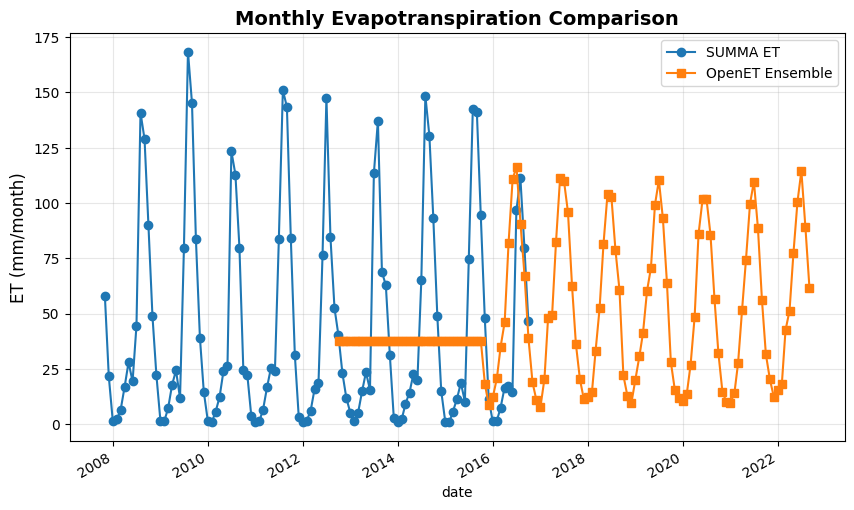

In [28]:
et = sim_ds['scalarLatHeatTotal'].resample(time='ME').mean()

# convert to W/m2 to mm/month
latent_heat = -et * 30 * 24 * 3600 / (2.45e6)  # mm/month
fig, ax = plt.subplots(figsize=(10, 6))
latent_heat.plot(ax=ax, label='SUMMA ET', marker='o')
open_et['et'].plot(ax=ax, label='OpenET Ensemble', marker='s')
ax.set_ylabel('ET (mm/month)', fontsize=12)
ax.set_title('Monthly Evapotranspiration Comparison', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

## Temperature Evaluation

In [29]:
obs_butte = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/snow/380_Butte_sntl_obs.csv", parse_dates=['datetime'], index_col='datetime')
obs_butte = obs_butte.loc['2014-10-01':'2016-09-30']

Monthly bias (SUMMA - obs): [-0.74849549 -0.31123318  0.74911117  1.11780398  1.33891568  1.7727408
  2.72345706  2.70118313  2.06480157  0.8095995  -1.78586565 -1.21286732]


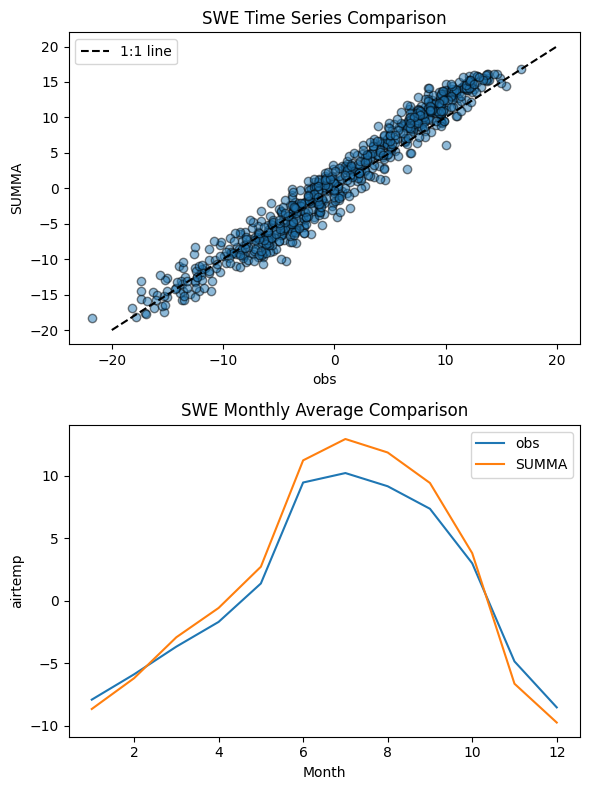

In [30]:
obs_butte_temp =((obs_butte['AIR TEMP'] - 32) * 5/9)
# obs_butte_temp = obs_butte_temp[(obs_butte_temp > -50) & (obs_butte_temp < 50)]
obs_butte_temp_monthly = obs_butte_temp.groupby(obs_butte_temp.index.month).mean()

sim_ds_airtemp = sim_ds['airtemp'].resample(time='D').mean().sel(time=slice('2014-10-01','2016-09-30')).squeeze() - 273.16
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,8))
axs[0].scatter(obs_butte_temp.values, sim_ds_airtemp.values, alpha=0.5, ec='k')
axs[0].plot([-20,20], [-20,20], 'k--', label='1:1 line')
axs[0].legend()
axs[0].set_xlabel('obs')
axs[0].set_ylabel('SUMMA')
axs[0].set_title("SWE Time Series Comparison")

# plot monthly average comparison
obs_butte_temp_monthly.plot(ax=axs[1], label='obs')
sim_ds_airtemp.groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("SWE Monthly Average Comparison")

print(f"Monthly bias (SUMMA - obs): {(sim_ds_airtemp.groupby('time.month').mean() - obs_butte_temp_monthly).values}")

## SWE evaluation

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'SWE Monthly Average Comparison')

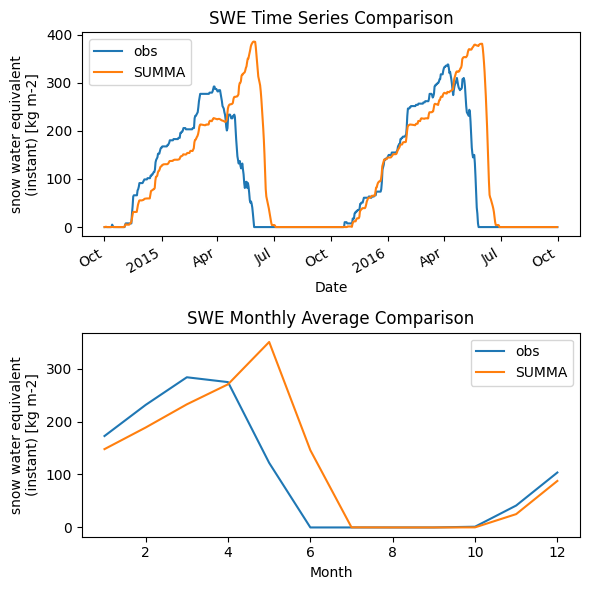

In [31]:
obs_butte_swe = obs_butte['SWE']*25.4
# filter extreme values
obs_butte_swe = obs_butte_swe[obs_butte_swe < 2000]
obs_butte_swe_monthly = obs_butte_swe.groupby(obs_butte_swe.index.month).mean()
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,6))
obs_butte_swe.plot(ax=axs[0], label='obs')
sim_ds['scalarSWE'].resample(time='D').mean().sel(time=slice('2014-10-01','2016-09-30')).plot(ax=axs[0], label='SUMMA')
axs[0].legend()
axs[0].set_xlabel('Date')
axs[0].set_title("SWE Time Series Comparison")

# plot monthly average comparison
obs_butte_swe_monthly.plot(ax=axs[1], label='obs')
sim_ds['scalarSWE'].resample(time='D').mean().sel(time=slice('2014-10-01','2016-09-30')).groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("SWE Monthly Average Comparison")

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


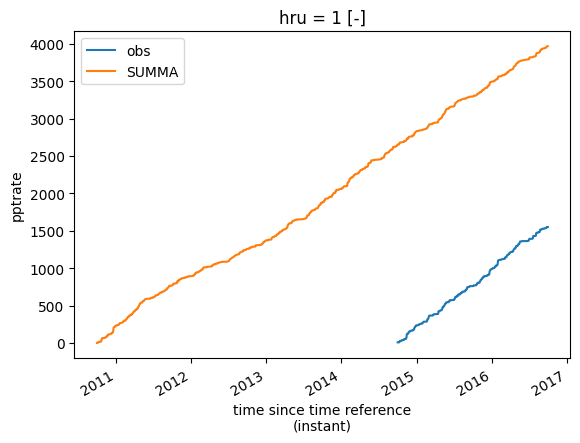

In [32]:
obs_butte_ppt = (obs_butte['PRECIPITATION']*25.4)
obs_butte_ppt = obs_butte_ppt[obs_butte_ppt < 500]
fig, ax = plt.subplots()
# ax.scatter(obs_butte_ppt.fillna(0).values, (sim_ds['pptrate']*3600).resample(time='1D').sum().sel(time=obs_butte_ppt.index.date).values, alpha=0.5)
obs_butte_ppt.cumsum().plot(ax=ax, label='obs')
(sim_ds['pptrate']*3600).resample(time='D').sum().sel(time=slice('2010-10-01','2018-09-30')).cumsum().plot(ax=ax, label='SUMMA')
ax.legend()

In [33]:
baseline_results = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/longterm_baseline/SUMMA/longterm_baseline_timestep.nc")
baseline_runoff = baseline_results['scalarTotalRunoff'].squeeze().resample(time='1D').mean() * shp_area

FileNotFoundError: [Errno 2] No such file or directory: '/scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/longterm_baseline/SUMMA/longterm_baseline_timestep.nc'

Integrated sums over the selected record:
      Rn:  3.993742e+06
      LE: -2.182807e+06
       H: -1.435216e+06
       G:  3.278493e+05
  Canopy:  4.280989e+04
  Canair: -4.390103e-02

Closure checks:
Correct SUMMA closure residual:  5.059749e+03
Mean absolute timestep residual:  1.964360e-01


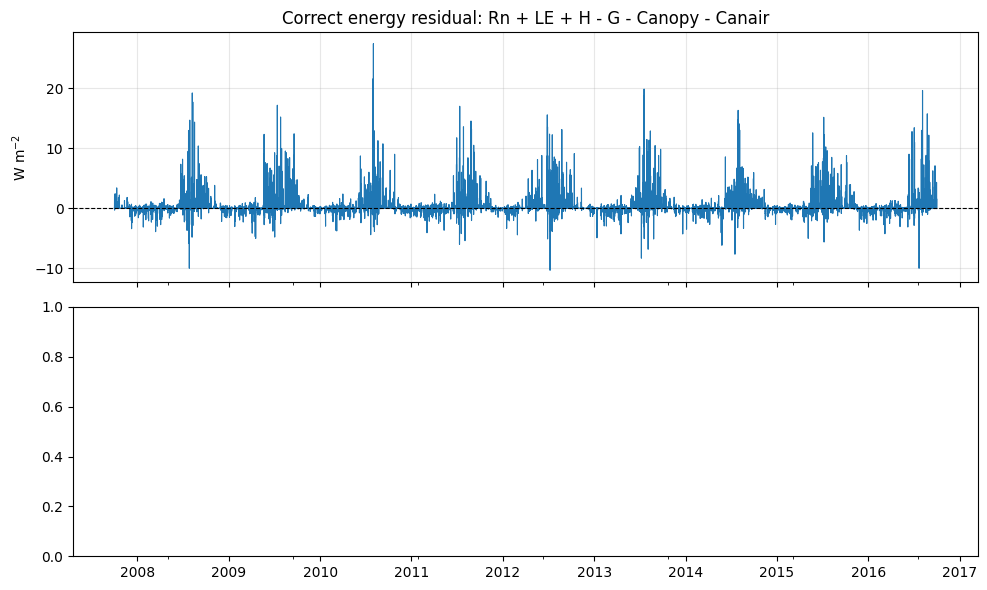

In [ ]:
energy_terms = {
    'Rn': sim_ds['scalarNetRadiation'].squeeze(),
    'LE': sim_ds['scalarLatHeatTotal'].squeeze(),
    'H': sim_ds['scalarSenHeatTotal'].squeeze(),
    'G': sim_ds['scalarGroundNetNrgFlux'].squeeze(),
    'Canopy': sim_ds['scalarCanopyNetNrgFlux'].squeeze(),
    'Canair': sim_ds['scalarCanairNetNrgFlux'].squeeze(),
}

energy_sums = {name: float(term.sum()) for name, term in energy_terms.items()}
print('Integrated sums over the selected record:')
for name, value in energy_sums.items():
    print(f'{name:>8s}: {value: .6e}')

# SUMMA sign convention here is:
# - Rn positive downward / available to the surface system
# - LE and H negative for upward turbulent losses from the surface
# - G, Canopy, and Canair positive when energy is stored in those reservoirs
residual_closed = (
    energy_terms['Rn']
    + energy_terms['LE']
    + energy_terms['H']
    - energy_terms['G']
    - energy_terms['Canopy']
    - energy_terms['Canair']
)

print('\nClosure checks:')
print(f"Correct SUMMA closure residual: {float(residual_closed.sum()): .6e}")
print(f"Mean absolute timestep residual: {float(np.abs(residual_closed).mean()): .6e}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
residual_closed.to_pandas().plot(ax=axes[0], lw=0.8)
axes[0].axhline(0.0, color='k', ls='--', lw=0.8)
axes[0].set_title('Correct energy residual: Rn + LE + H - G - Canopy - Canair')
axes[0].set_ylabel('W m$^{-2}$')
axes[0].grid(True, alpha=0.3)

plt.tight_layout()

KeyError: "No variable named 'scalarTotalET'. Did you mean one of ('scalarTotalRunoff', 'scalarTotalSoilLiq', 'scalarTotalSoilIce', 'scalarSenHeatTotal', 'scalarLatHeatTotal', 'scalarSWE')?"

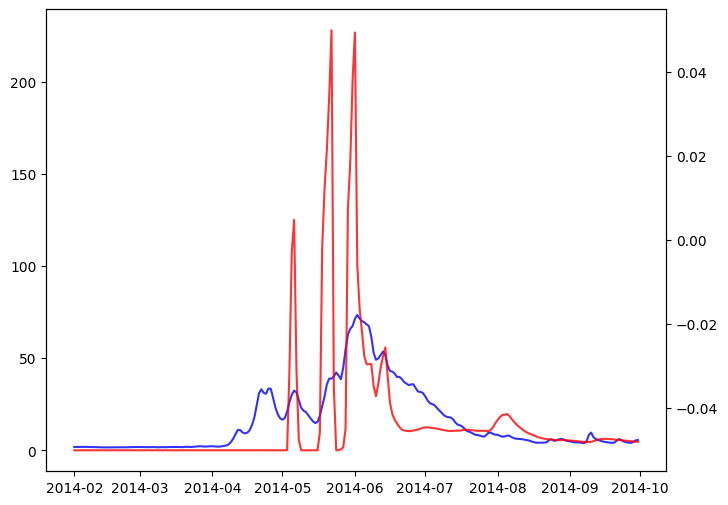

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
start, end = '2014-02-01', '2014-09-30'  # Example: WY2017

# Time series comparison (top left)
ax.plot(obs_valid.loc[start:end].index, obs_valid.loc[start:end].values, 'b-', 
         label='USGS Observed', linewidth=1.5, alpha=0.8)
ax.plot(sim_valid.loc[start:end].index, sim_valid.loc[start:end].values, 'r-', 
         label='SUMMA', linewidth=1.5, alpha=0.8)
# ax.plot(baseline_runoff.to_pandas().loc[start:end].index, baseline_runoff.to_pandas().loc[start:end].values, 'g-',label='Baseline Runoff', linewidth=1.5, alpha=0.8)
ax2 = ax.twinx()
ax2.plot(obs_butte_swe.loc[start:end].index, obs_butte_swe.loc[start:end].values, 'b--', label='obs SWE', linewidth=1.5, alpha=0.8)
ax2.plot(sim_ds['scalarTotalET'].squeeze().sel(time=slice(start, end)).to_pandas(), 'c--', label='Simulated SWE', linewidth=1.5, alpha=0.8)
# ax2.plot(baseline_results['scalarTotalSoilLiq'].squeeze().sel(time=slice(start, end)).to_pandas(), 'm--', label='Baseline SWE', linewidth=1.5, alpha=0.8)

ax.set_ylabel('Discharge (m³/s)', fontsize=11)
ax.set_title('Streamflow Time Series', fontweight='bold')
ax.legend()
ax2.legend(loc='upper left')
ax.grid(True, alpha=0.3)

## Summary: Lumped Basin-Scale Streamflow Simulation
This tutorial successfully demonstrated the critical scaling transition from point-scale process validation to basin-scale integrated streamflow simulation using CONFLUENCE. Through the East River at Almont case study, we illustrated how the same standardized workflow framework seamlessly scales from individual site validation to watershed-scale prediction while maintaining scientific rigor and computational efficiency.

## Key Methodological Achievements
The tutorial established watershed-scale modeling capabilities by successfully transitioning from point measurements to integrated basin response through automated watershed delineation and lumped representation strategies. Spatial aggregation techniques were demonstrated through catchment-averaged characteristic development that captures essential watershed properties while maintaining computational tractability. Integrated process simulation was achieved by coupling SUMMA's process-based physics with mizuRoute streamflow routing to transform distributed runoff generation into streamflow predictions at the basin outlet.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to simulate integrated watershed response through the successful representation of snow accumulation, melt, and runoff generation processes across elevation gradients in a mountain environment. Seasonal flow regime capture was validated through comparison with long-term Water Survey of Canada observations, showing the model's capability to represent pronounced spring freshet patterns and low-flow periods. Water balance closure was maintained through conservation of mass principles while scaling from point processes to basin-integrated streamflow generation.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless scaling capabilities by applying identical workflow principles from point validation through basin-scale prediction without requiring fundamental architectural changes. The model-agnostic preprocessing approach proved equally effective for basin-averaged forcing and validation data preparation, reinforcing the framework's broad applicability. Computational efficiency was demonstrated through lumped representation strategies that enable rapid execution suitable for calibration, uncertainty analysis, and operational applications while maintaining process-based physical realism.

This foundation in lumped basin modeling establishes the essential principles for understanding watershed-scale hydrological behavior and 
prepares for the spatial complexity introduced in semi-distributed and fully distributed modeling approaches in subsequent tutorials.

### Next Focus: Semi-Distributed Watershed Modelling 

**Ready to explore Semi-Distributed basin simulations?** → **[Tutorial 02b: Basin Scale - Semi-Distributed Watershed](./02b_basin_semi_distributed.ipynb)**

## Short Warm-Start Test Run (2-Year)
Uses an existing `warmState.nc` from the prior long-term baseline to run a short screening simulation.
- Run window: `2010-10-01 00:00` to `2012-09-30 23:00`
- Evaluate year 2 only: `2011-10-01` to `2012-09-30`
- `fileManager.txt` is backed up and restored automatically.

Backed up fileManager: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/fileManager.backup_warmstart_short_2010_2012.txt
Updated fileManager for short warm-start run:
  simStartTime: 2010-10-01 00:00
  simEndTime:   2012-09-30 23:00
  init state:   warmState.nc
  out prefix:   warmstart_short_2010_2012
  outputPath:   /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/warmstart_short_2010_2012/SUMMA
2026-03-11 16:19:38 ● Starting model runs
2026-03-11 16:19:38 ● Running model: SUMMA
2026-03-11 16:19:38 ● Starting SUMMA run


2026-03-11 16:20:09 ● SUMMA run completed successfully
Short warm-start run complete
Restored original fileManager from: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/settings/SUMMA/fileManager.backup_warmstart_short_2010_2012.txt
Output file: /scratch/dlhogan/ess-project-data/domain_East_River_lumped/simulations/warmstart_short_2010_2012/SUMMA/warmstart_short_2010_2012_timestep.nc
Eval window timesteps: 366


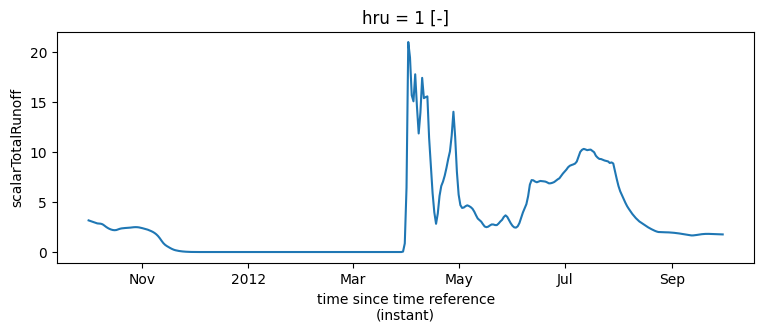

In [ ]:
from pathlib import Path
import shutil
import xarray as xr

# --- user-adjustable settings ---
short_exp_id = "warmstart_short_2010_2012"
short_start = "2010-10-01 00:00"
short_end = "2012-09-30 23:00"
eval_start = "2011-10-01"
eval_end = "2012-09-30"

project_domain_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}"
settings_dir = project_domain_dir / "settings" / "SUMMA"
file_manager = settings_dir / "fileManager.txt"
warm_state = settings_dir / "warmState.nc"

if not warm_state.exists():
    raise FileNotFoundError(
        f"Warm state not found: {warm_state}\n"
        "Create it first (e.g., from longterm_baseline) before running this test."
    )

short_out_dir = project_domain_dir / "simulations" / short_exp_id / "SUMMA"
short_out_dir.mkdir(parents=True, exist_ok=True)

backup_fm = settings_dir / f"fileManager.backup_{short_exp_id}.txt"
shutil.copy2(file_manager, backup_fm)
print(f"Backed up fileManager: {backup_fm}")


def _replace_line_value(line, key, value):
    if not line.strip().startswith(key):
        return line, False
    if "'" not in line:
        # Keep parser happy with canonical quoted format.
        return f"{key:<20} '{value}'\n", True
    left = line[: line.find("'")]
    right = line[line.rfind("'") + 1 :]
    return f"{left}'{value}'{right}", True


with open(file_manager, "r") as f:
    fm_lines = f.readlines()

replacements = {
    "simStartTime": short_start,
    "simEndTime": short_end,
    "initConditionFile": warm_state.name,
    "outFilePrefix": short_exp_id,
    "outputPath": str(short_out_dir) + "/",
}

new_lines = []
seen = {k: False for k in replacements}
for line in fm_lines:
    updated_line = line
    for key, value in replacements.items():
        updated_line, changed = _replace_line_value(updated_line, key, value)
        if changed:
            seen[key] = True
            break
    new_lines.append(updated_line)

missing = [k for k, found in seen.items() if not found]
if missing:
    raise RuntimeError(f"Missing required keys in fileManager.txt: {missing}")

with open(file_manager, "w") as f:
    f.writelines(new_lines)

print("Updated fileManager for short warm-start run:")
print(f"  simStartTime: {short_start}")
print(f"  simEndTime:   {short_end}")
print(f"  init state:   {warm_state.name}")
print(f"  out prefix:   {short_exp_id}")
print(f"  outputPath:   {short_out_dir}")

# Keep logging/output paths consistent with this short experiment id.
prev_exp_id = confluence.config.get("EXPERIMENT_ID", None)
confluence.config["EXPERIMENT_ID"] = short_exp_id

try:
    confluence.managers['model'].run_models()
    print("Short warm-start run complete")
finally:
    shutil.copy2(backup_fm, file_manager)
    if prev_exp_id is not None:
        confluence.config["EXPERIMENT_ID"] = prev_exp_id
    print(f"Restored original fileManager from: {backup_fm}")

out_nc = short_out_dir / f"{short_exp_id}_timestep.nc"
if not out_nc.exists():
    nc_list = sorted(short_out_dir.glob("*_timestep.nc"))
    if not nc_list:
        raise FileNotFoundError(f"No *_timestep.nc found in {short_out_dir}")
    out_nc = nc_list[-1]

short_ds = xr.open_dataset(out_nc)
short_q = short_ds['scalarTotalRunoff'].squeeze() * shp_area
short_q_eval = short_q.sel(time=slice(eval_start, eval_end)).resample(time='1D').mean()

print(f"Output file: {out_nc}")
print(f"Eval window timesteps: {short_q_eval.sizes.get('time', 'n/a')}")
short_q_eval.plot(figsize=(9, 3), label='short warm-start runoff')

## Warm-Start Sensitivity Sweep (2-Year)
This runs a short warm-start control + one-at-a-time perturbations to rank which parameters best reduce late-summer retention.
- Spinup year: WY2011
- Evaluation year: WY2012 (`2011-10-01` to `2012-09-30`)
- Focus metrics: JAS flow bias and JAS recession slope mismatch

Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
[1/3] Running control ... local edits=5, basin edits=4
2026-03-11 16:20:09 ● Starting model runs
2026-03-11 16:20:09 ● Running model: SUMMA
2026-03-11 16:20:09 ● Starting SUMMA run
2026-03-11 16:20:40 ● SUMMA run completed successfully
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated localParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
Updated basinParamInfo.txt:
  ✓ Reformatted 0 lines to 4-decimal precision
[2/3] Running aquiferHydCond_x3 ... local edits=5, basin edits=4
2026-03-11 16:20:40 ● Starting model runs
2026-03-11 16:20:40 ● Running model: SUMMA
2026-03-11 16:

,scenario,jas_bias_cms,sim_jas_log_slope,obs_jas_log_slope,slope_mismatch,score,output_nc
0,control,2.248848,-0.025294,-0.012292,0.013002,3.549025,/scratch/dlhogan/ess-project-data/domain_East_...
1,aquiferHydCond_x3,2.248848,-0.025294,-0.012292,0.013002,3.549025,/scratch/dlhogan/ess-project-data/domain_East_...
2,k_soil_x2,2.248848,-0.025294,-0.012292,0.013002,3.549025,/scratch/dlhogan/ess-project-data/domain_East_...


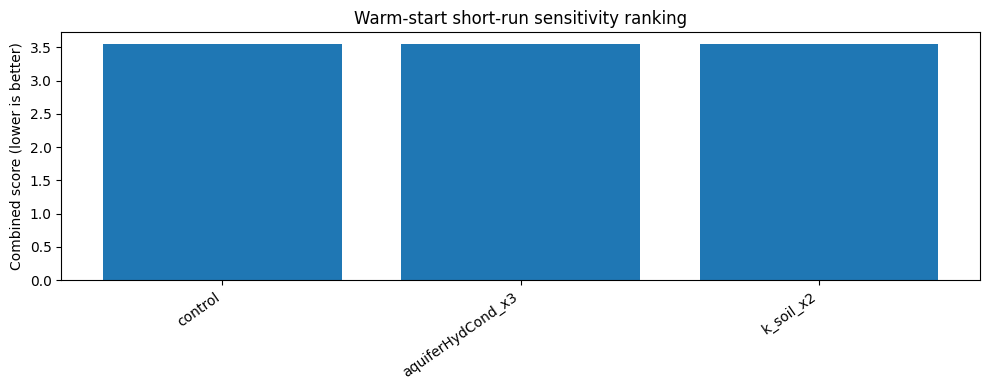

Restored fileManager and parameter files to pre-sweep state.


In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import shutil
from pathlib import Path
from utils.custom.adjust_settings import update_and_reformat_parameter_file, _format_parameter_value

# -----------------------------------------------------------------------------
# USER SETTINGS
# -----------------------------------------------------------------------------
run_start = "2010-10-01 00:00"
run_end = "2012-09-30 23:00"
eval_start = "2011-10-01"
eval_end = "2012-09-30"

project_domain_dir = Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}"
settings_dir = project_domain_dir / "settings" / "SUMMA"
file_manager = settings_dir / "fileManager.txt"
local_param_file = settings_dir / "localParamInfo.txt"
basin_param_file = settings_dir / "basinParamInfo.txt"
warm_state = settings_dir / "warmState.nc"

obs_path = project_domain_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime']).set_index('datetime')
obs_eval = obs_df['discharge_cms'].resample('D').mean().loc[eval_start:eval_end]

if not warm_state.exists():
    raise FileNotFoundError(f"Missing warm state: {warm_state}")

# Baseline parameter values (current tuned set)
base_local = {
    'k_soil': 9.4e-6,
    'theta_sat': 0.5160,
    'theta_res': 0.0270,
    'aquiferScaleFactor': 50.0,
    'rootingDepth': 6.876,
}
base_basin = {
    'basin__aquiferHydCond': 0.0010,
    'basin__aquiferScaleFactor': 50.0,
    'routingGammaShape': 2.5,
    'routingGammaScale': 4.6e4,
}

# One-at-a-time perturbations aimed at reducing late-summer flow retention.
# control keeps original values for reference.
scenarios = {
    'control': {'local': {}, 'basin': {}},
    'aquiferHydCond_x3': {'local': {}, 'basin': {'basin__aquiferHydCond': base_basin['basin__aquiferHydCond'] * 100.0}},
    # 'aquiferScale_half': {'local': {'aquiferScaleFactor': base_local['aquiferScaleFactor'] * 0.5}, 'basin': {'basin__aquiferScaleFactor': base_basin['basin__aquiferScaleFactor'] * 0.5}},
    # 'rootingDepth_60pct': {'local': {'rootingDepth': base_local['rootingDepth'] * 0.6}, 'basin': {}},
    # 'routingGammaScale_30pct': {'local': {}, 'basin': {'routingGammaScale': base_basin['routingGammaScale'] * 0.3}},
    'k_soil_x2': {'local': {'k_soil': min(base_local['k_soil'] * 100.0, 1.0e-3)}, 'basin': {}},
}


def _apply_updates_with_fallback(file_path, updates):
    # Try standard updater first.
    res = update_and_reformat_parameter_file(file_path, updates, reformat_all=True)
    updated_count = int(res.get('updated_count', 0)) if isinstance(res, dict) else 0
    if updated_count > 0:
        return updated_count

    # Fallback: syntax-preserving pipe-delimited replacement.
    with open(file_path, 'r') as f:
        lines = f.readlines()

    new_lines = []
    n = 0
    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith('!') or '|' not in line:
            new_lines.append(line)
            continue

        parts = line.rstrip('\n').split('|')
        if len(parts) < 4:
            new_lines.append(line)
            continue

        key = parts[0].strip()
        if key in updates:
            parts[1] = f" {_format_parameter_value(updates[key])} "
            line = '|'.join(parts) + '\n'
            n += 1

        new_lines.append(line)

    if n > 0:
        with open(file_path, 'w') as f:
            f.writelines(new_lines)

    return n


def _replace_line_value(line, key, value):
    if not line.strip().startswith(key):
        return line, False
    if "'" not in line:
        return f"{key:<20} '{value}'\\n", True
    left = line[: line.find("'")]
    right = line[line.rfind("'") + 1 :]
    return f"{left}'{value}'{right}", True


def _update_file_manager(sim_id, out_dir):
    with open(file_manager, 'r') as f:
        lines = f.readlines()

    replacements = {
        'simStartTime': run_start,
        'simEndTime': run_end,
        'initConditionFile': warm_state.name,
        'outFilePrefix': sim_id,
        'outputPath': str(out_dir) + '/',
    }

    new_lines = []
    seen = {k: False for k in replacements}
    for line in lines:
        updated = line
        for key, value in replacements.items():
            updated, changed = _replace_line_value(updated, key, value)
            if changed:
                seen[key] = True
                break
        new_lines.append(updated)

    missing = [k for k, found in seen.items() if not found]
    if missing:
        raise RuntimeError(f"Missing keys in fileManager.txt: {missing}")

    with open(file_manager, 'w') as f:
        f.writelines(new_lines)


def _jas_metrics(sim_daily, obs_daily):
    common = sim_daily.index.intersection(obs_daily.index)
    sim = sim_daily.loc[common]
    obs = obs_daily.loc[common]

    jas_mask = common.month.isin([7, 8, 9])
    sim_jas = sim.loc[jas_mask]
    obs_jas = obs.loc[jas_mask]

    jas_bias = float((sim_jas - obs_jas).mean())

    # Recession slope in log-space over JAS means more negative = faster recession.
    x = np.arange(len(sim_jas), dtype=float)
    eps = 1e-6
    sim_slope = float(np.polyfit(x, np.log(sim_jas.values + eps), 1)[0])
    obs_slope = float(np.polyfit(x, np.log(obs_jas.values + eps), 1)[0])
    slope_mismatch = abs(sim_slope - obs_slope)

    return jas_bias, sim_slope, obs_slope, slope_mismatch


# Backups so this cell is reversible.
fm_bak = settings_dir / "fileManager.backup_sweep.txt"
local_bak = settings_dir / "localParamInfo.backup_sweep.txt"
basin_bak = settings_dir / "basinParamInfo.backup_sweep.txt"
shutil.copy2(file_manager, fm_bak)
shutil.copy2(local_param_file, local_bak)
shutil.copy2(basin_param_file, basin_bak)

results = []
prev_exp_id = confluence.config.get('EXPERIMENT_ID', None)

try:
    for i, (scenario, updates) in enumerate(scenarios.items(), start=1):
        sim_id = f"warmstart_sweep_{scenario}"
        out_dir = project_domain_dir / "simulations" / sim_id / "SUMMA"
        out_dir.mkdir(parents=True, exist_ok=True)

        # Reset to baseline values before each perturbation.
        n_local_base = _apply_updates_with_fallback(local_param_file, base_local)
        n_basin_base = _apply_updates_with_fallback(basin_param_file, base_basin)

        local_updates = dict(base_local)
        basin_updates = dict(base_basin)
        local_updates.update(updates['local'])
        basin_updates.update(updates['basin'])

        n_local_scn = _apply_updates_with_fallback(local_param_file, local_updates)
        n_basin_scn = _apply_updates_with_fallback(basin_param_file, basin_updates)

        _update_file_manager(sim_id, out_dir)
        confluence.config['EXPERIMENT_ID'] = sim_id

        print(f"[{i}/{len(scenarios)}] Running {scenario} ... local edits={n_local_scn}, basin edits={n_basin_scn}")
        confluence.managers['model'].run_models()

        nc_file = out_dir / f"{sim_id}_timestep.nc"
        if not nc_file.exists():
            nc_list = sorted(out_dir.glob("*_timestep.nc"))
            if not nc_list:
                raise FileNotFoundError(f"No *_timestep.nc found for {scenario}")
            nc_file = nc_list[-1]

        ds = xr.open_dataset(nc_file)
        sim_q = (ds['scalarTotalRunoff'].squeeze() * shp_area).sel(time=slice(eval_start, eval_end)).resample(time='D').mean().to_pandas()
        ds.close()

        jas_bias, sim_slope, obs_slope, slope_mismatch = _jas_metrics(sim_q, obs_eval)

        # Combined score: lower is better.
        score = abs(jas_bias) + 100.0 * slope_mismatch

        results.append({
            'scenario': scenario,
            'jas_bias_cms': jas_bias,
            'sim_jas_log_slope': sim_slope,
            'obs_jas_log_slope': obs_slope,
            'slope_mismatch': slope_mismatch,
            'score': score,
            'output_nc': str(nc_file),
        })

    results_df = pd.DataFrame(results).sort_values('score').reset_index(drop=True)
    display(results_df)

    plt.figure(figsize=(10, 4))
    plt.bar(results_df['scenario'], results_df['score'])
    plt.xticks(rotation=35, ha='right')
    plt.ylabel('Combined score (lower is better)')
    plt.title('Warm-start short-run sensitivity ranking')
    plt.tight_layout()
    plt.show()

finally:
    shutil.copy2(fm_bak, file_manager)
    shutil.copy2(local_bak, local_param_file)
    shutil.copy2(basin_bak, basin_param_file)
    if prev_exp_id is not None:
        confluence.config['EXPERIMENT_ID'] = prev_exp_id
    print('Restored fileManager and parameter files to pre-sweep state.')